# 🎵 Spotify Hit Şarkı Tahmini
## End-to-End Makine Öğrenmesi Projesi

---

## 1. Problem Tanımı

Müzik endüstrisi, yılda milyonlarca yeni şarkının yayınlandığı ve 
rekabetin son derece yoğun olduğu bir alan. Bir şarkının "hit" olup 
olmayacağını önceden tahmin edebilmek; plak şirketleri, sanatçılar ve 
müzik platformları için büyük stratejik değer taşır.

Bu proje şu soruyu yanıtlamayı hedefler:

> **Bir şarkının ses özellikleri ve metadata bilgileri kullanılarak,
> o şarkının Spotify'da "hit" olup olmayacağı tahmin edilebilir mi?**

---

## 2. Veri Seti

Analizde kullanılan `spotify_songs.csv` veri seti, Spotify'ın resmi 
API'si aracılığıyla derlenmiş olup **32.833 satır** ve **23 değişken** 
içermektedir. Veri seti üç ana kategoride incelenebilir:

| Kategori | Değişkenler | Açıklama |
|---|---|---|
| **Kimlik & Meta** | `track_id`, `track_name`, `track_artist`, `track_album_*`, `playlist_*` | Şarkı, albüm ve playlist tanımlayıcıları |
| **Ses Özellikleri** | `danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `key`, `mode`, `duration_ms` | Spotify'ın algoritması tarafından hesaplanan müzikal özellikler |
| **Hedef** | `track_popularity` | 0–100 arası Spotify popülerlik skoru |

---

## 3. Metodoloji

Proje, aşağıdaki adımlardan oluşan uçtan uca bir makine öğrenimi 
pipeline'ı üzerine inşa edilmiştir:
```
Ham Veri → Temizlik → EDA → Özellik Mühendisliği → 
Veri Bölme → Encoding → Ölçeklendirme → Modelleme → 
Değerlendirme → Yorumlama
```

Metodolojik olarak öne çıkan kararlar:

- **Eşik Belirleme:** "Hit" tanımı keyfi değil, veri temizliği 
  sonrasındaki istatistiksel dağılımdan (75. yüzdelik dilim) 
  türetilmiştir.
- **Veri Sızıntısı Önleme:** Target Encoding işlemi, train/test 
  bölmesinden *sonra* ve yalnızca eğitim verisi üzerinden yapılmıştır.
- **Değerlendirme Metriği:** Dengesiz sınıf dağılımı (~74/26) nedeniyle 
  temel metrik olarak **F1-Skoru** kullanılmıştır. Accuracy bu tür 
  problemlerde yanıltıcı olur.

---

## 4. Kullanılan Teknolojiler

| Araç | Kullanım Amacı |
|---|---|
| `pandas` / `numpy` | Veri manipülasyonu ve sayısal hesaplama |
| `matplotlib` / `seaborn` | Görselleştirme |
| `scikit-learn` | Ön işleme, bölme, değerlendirme metrikleri |
| `xgboost` | Sınıflandırma modeli |

## Adım 2 — Ortam Kurulumu & Kütüphaneler

Analizin tamamında kullanılacak kütüphaneler, görselleştirme ayarları 
ve proje sabitleri bu adımda tek bir yerde tanımlanmaktadır.

Sabitleri en başta merkezi olarak tanımlamak iyi bir pratiktir:
ilerleyen adımlarda herhangi bir parametreyi değiştirmek istediğimizde
tek bir hücreyi güncellemek yeterli olur — "sihirli sayı" hatalarının
önüne geçilmiş olur.

> **Not:** `HIT_THRESHOLD = 58` değeri şu an sabit olarak 
> tanımlanmaktadır. Bu eşiğin istatistiksel gerekçesi 
> **Adım 5**'te (EDA — Hedef Değişken Analizi) detaylı olarak 
> ortaya konacaktır.

In [1]:
# ─── Temel Kütüphaneler ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─── Görselleştirme ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ─── Makine Öğrenimi — Ön İşleme & Değerlendirme ─────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# ─── Model ────────────────────────────────────────────────────────────────────
import xgboost
from xgboost import XGBClassifier

# ─── Görselleştirme Ayarları ──────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    'figure.figsize'   : (12, 6),
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 12,
})

# Proje genelinde tutarlı renk paleti
PALETTE_BINARY = ['#636EFA', '#EF553B']  # 0: mavi (non-hit), 1: kırmızı (hit)
PALETTE_GENRE  = 'tab10'
PALETTE_CORR   = 'coolwarm'
PALETTE_SEQ    = 'viridis'

# ─── Proje Sabitleri ──────────────────────────────────────────────────────────
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
HIT_THRESHOLD = 58   # Adım 5'te istatistiksel olarak gerekçelendirilecek

# ─── Özet ────────────────────────────────────────────────────────────────────
print("✅ Kütüphaneler yüklendi.")
print(f"   pandas   : {pd.__version__}")
print(f"   xgboost  : {xgboost.__version__}")
print()
print("📌 Proje Sabitleri")
print(f"   RANDOM_STATE  = {RANDOM_STATE}")
print(f"   TEST_SIZE     = {TEST_SIZE}")
print(f"   HIT_THRESHOLD = {HIT_THRESHOLD}  ← Adım 5'te gerekçelendirilecek")

✅ Kütüphaneler yüklendi.
   pandas   : 2.2.3
   xgboost  : 2.0.3

📌 Proje Sabitleri
   RANDOM_STATE  = 42
   TEST_SIZE     = 0.2
   HIT_THRESHOLD = 58  ← Adım 5'te gerekçelendirilecek


## Adım 3 — Veri Yükleme & İlk İnceleme

Herhangi bir temizlik veya modelleme adımına geçmeden önce veriyi 
ham haliyle anlamak gerekir. Bu adımda üç temel soruya yanıt aranıyor:

1. **Veri ne kadar büyük, sütunlar ne tür bilgiler içeriyor?**
2. **Sayısal değişkenlerin istatistiksel dağılımı nasıl?**
3. **Kategorik değişkenlerde kaç benzersiz değer var?**

Bu sorulara verilen yanıtlar ilerleyen adımlardaki kararları 
doğrudan şekillendirecek — hangi sütunlar atılacak, hangileri 
encode edilecek, hedef eşiği nerede belirlenmeli.

### 3.1 — Veri Yükleme & Yapısal İnceleme

Veri setini yükleyip temel yapısına bakıyoruz: boyut, sütun tipleri 
ve eksik değer varlığı. Bu ilk bakış bize verinin genel "sağlığı" 
hakkında fikir verecek.

In [2]:
# ─── Veri Yükleme ─────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/spotify-songs-2020/spotify_songs.csv')

print("=" * 55)
print(f"  Satır Sayısı  : {df.shape[0]:,}")
print(f"  Sütun Sayısı  : {df.shape[1]}")
print("=" * 55)

# ─── Sütun Tipleri, Eksik Değer & Benzersiz Değer ─────────────────────────────
info_df = pd.DataFrame({
    'Tip'          : df.dtypes,
    'Eksik Sayısı' : df.isnull().sum(),
    'Eksik (%)'    : (df.isnull().sum() / len(df) * 100).round(3),
    'Benzersiz'    : df.nunique()
})

print("\n📋 Sütun Özeti:\n")
print(info_df.to_string())

  Satır Sayısı  : 32,833
  Sütun Sayısı  : 23

📋 Sütun Özeti:

                              Tip  Eksik Sayısı  Eksik (%)  Benzersiz
track_id                   object             0      0.000      28356
track_name                 object             5      0.015      23449
track_artist               object             5      0.015      10692
track_popularity            int64             0      0.000        101
track_album_id             object             0      0.000      22545
track_album_name           object             5      0.015      19743
track_album_release_date   object             0      0.000       4530
playlist_name              object             0      0.000        449
playlist_id                object             0      0.000        471
playlist_genre             object             0      0.000          6
playlist_subgenre          object             0      0.000         24
danceability              float64             0      0.000        822
energy                    f

### 3.2 — Sayısal Değişken İstatistikleri

`describe()` çıktısı bize hedef değişkenimiz olan `track_popularity` 
hakkında ilk kritik ipucunu veriyor.

Dikkat çeken noktalar:

- `track_popularity` ortalaması **~42**, medyanı **45** — 
  dağılımın simetrik olmadığına dair ilk işaret.
- `instrumentalness` ortalaması sıfıra çok yakın ama maksimumu 1.0 —
  sağa çarpık bir dağılım bekliyoruz.
- `duration_ms` minimumu **4.000 ms (4 saniye)** — bu bir şarkı 
  olamaz, veri kalitesi adımında ele alınacak.

> **İlk Gözlem:** `track_popularity` sütununun 75. yüzdelik dilimi 
> **62.0** görünüyor. Ancak bu değer ham veri üzerinden hesaplanıyor. 
> Temizlik sonrasında bu sayının değişebileceğini not edelim — 
> "Hit" eşiğini **temiz veri üzerinden** belirleyeceğiz.

In [3]:
# ─── Sayısal Değişken İstatistikleri ─────────────────────────────────────────
desc = df.describe().T
desc.columns = ['N', 'Ort.', 'Std.', 'Min', 'Q1', 'Medyan', 'Q3', 'Maks.']
desc['N'] = desc['N'].astype(int)

print("📊 Sayısal Değişken Özeti:\n")
print(desc.round(3).to_string())

print("\n" + "─" * 55)
print(f"  track_popularity → Q3 (ham veri) : "
      f"{df['track_popularity'].quantile(0.75):.1f}")
print(f"  duration_ms      → Min           : "
      f"{df['duration_ms'].min():,} ms  ⚠️  şüpheli")
print("─" * 55)

📊 Sayısal Değişken Özeti:

                      N        Ort.       Std.       Min          Q1      Medyan          Q3       Maks.
track_popularity  32833      42.477     24.984     0.000      24.000      45.000      62.000     100.000
danceability      32833       0.655      0.145     0.000       0.563       0.672       0.761       0.983
energy            32833       0.699      0.181     0.000       0.581       0.721       0.840       1.000
key               32833       5.374      3.612     0.000       2.000       6.000       9.000      11.000
loudness          32833      -6.719      2.988   -46.448      -8.171      -6.166      -4.645       1.275
mode              32833       0.566      0.496     0.000       0.000       1.000       1.000       1.000
speechiness       32833       0.107      0.101     0.000       0.041       0.062       0.132       0.918
acousticness      32833       0.175      0.220     0.000       0.015       0.080       0.255       0.994
instrumentalness  32833     

### 3.3 — Kategorik Değişken İstatistikleri

Kategorik değişkenler içinde en dikkat çekici olan `track_artist` 
sütunudur: **10.000'den fazla** benzersiz sanatçı içeriyor.

Bu, standart One-Hot Encoding'in bu sütun için **tamamen uygunsuz** 
olduğu anlamına gelir — 10.000+ binary sütun hem hesaplama maliyeti 
hem de model performansı açısından kabul edilemez.

Encoding stratejisi şimdilik zihnimizde şekilleniyor:

| Sütun | Benzersiz Değer | Strateji |
|---|---|---|
| `track_artist` | ~10.000+ | **Target Encoding** |
| `playlist_genre` | 6 | One-Hot Encoding |
| `playlist_subgenre` | 24 | **Target Encoding** |
| `playlist_name`, `playlist_id` | Çok yüksek | **Drop** (anlamsız) |

Ayrıca `track_album_release_date` sütunu metin formatında — 
bu sütundan anlamlı sayısal özellikler türetmemiz gerekecek 
(yıl, ay, şarkı yaşı).

In [4]:
# ─── Kategorik Değişken Özeti ─────────────────────────────────────────────────
cat_df = df.select_dtypes(include='object')

cat_summary = pd.DataFrame({
    'Benzersiz'          : cat_df.nunique(),
    'En Sık Değer'       : cat_df.mode().iloc[0],
    'Frekans'            : [
        cat_df[c].value_counts().iloc[0] for c in cat_df.columns
    ],
    'Frekans (%)'        : [
        round(cat_df[c].value_counts().iloc[0] / len(df) * 100, 2)
        for c in cat_df.columns
    ]
})

print("📋 Kategorik Değişken Özeti:\n")
print(cat_summary.to_string())

print("\n" + "─" * 55)
print("  ⚠️  Encoding Stratejisi (ön değerlendirme):")
print(f"  track_artist      → {df['track_artist'].nunique():,} değer "
      f"→ Target Encoding")
print(f"  playlist_genre    → {df['playlist_genre'].nunique()} değer  "
      f"→ One-Hot Encoding")
print(f"  playlist_subgenre → {df['playlist_subgenre'].nunique()} değer "
      f"→ Target Encoding")
print(f"  playlist_name/id  → yüksek kardinalite → Drop")
print(f"  release_date      → metin formatı → parse edilecek")
print("─" * 55)

📋 Kategorik Değişken Özeti:

                          Benzersiz               En Sık Değer  Frekans  Frekans (%)
track_id                      28356     7BKLCZ1jbUBVqRi2FVlTVw       10         0.03
track_name                    23449                     Poison       22         0.07
track_artist                  10692              Martin Garrix      161         0.49
track_album_id                22545     5L1xcowSxwzFUSJzvyMp48       42         0.13
track_album_name              19743              Greatest Hits      139         0.42
track_album_release_date       4530                 2020-01-10      270         0.82
playlist_name                   449            Indie Poptimism      308         0.94
playlist_id                     471     4JkkvMpVl4lSioqQjeAL0q      247         0.75
playlist_genre                    6                        edm     6043        18.41
playlist_subgenre                24  progressive electro house     1809         5.51

───────────────────────────────────

## Adım 4 — Veri Kalitesi & Temizlik

Adım 3'te verinin genel yapısına baktık ve birkaç şüpheli nokta 
dikkatimizi çekti: bazı sütunlarda eksik değer olabilir, 
`duration_ms` minimumu şüpheliydi ve aynı şarkının birden fazla 
playlist'te görünmesi nedeniyle duplikeler olabilir.

Bu adımda üç başlık sistematik olarak ele alınıyor:

1. **Eksik Değer Analizi** — Hangi sütunlarda eksiklik var, 
   yapısal mı yoksa rastgele mi?
2. **Duplike Analizi** — Aynı şarkı birden fazla playlist'te 
   görünüyor olabilir. `track_id` bazında gerçek duplikeler 
   tespit edilecek ve temizlenecek.
3. **Aykırı Değer & Veri Giriş Hatası** — Ses özelliklerinde 
   IQR yöntemiyle aykırılıklar incelenecek; `duration_ms` 
   için şüpheli uç değerler filtrelenecek.

> ⚠️ **Önemli:** "Hit" eşiğini temiz veri üzerinden belirleyeceğiz. 
> Bu nedenle temizlik adımının modelleme öncesinde eksiksiz 
> tamamlanması kritik önem taşıyor.

### 4.1 — Eksik Değer Analizi

İlk bakışta veri oldukça temiz görünüyordu. Ama tam olarak 
nerede, kaç satırda eksiklik olduğunu sayısal ve görsel 
olarak doğrulayalım.

⚠️  Eksik Değer Bulunan Sütunlar:

                  Eksik Sayısı  Eksik (%)
track_name                   5     0.0152
track_artist                 5     0.0152
track_album_name             5     0.0152


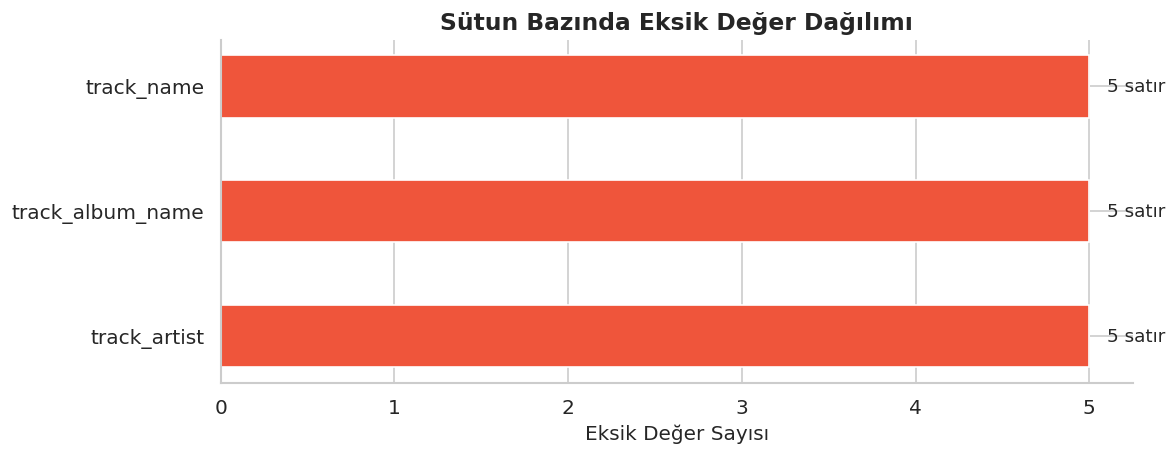


✅ Eksik değer temizliği sonrası: 32,828 satır


In [5]:
# ─── Eksik Değer Tablosu ──────────────────────────────────────────────────────
missing = pd.DataFrame({
    'Eksik Sayısı' : df.isnull().sum(),
    'Eksik (%)'    : (df.isnull().sum() / len(df) * 100).round(4)
}).query('`Eksik Sayısı` > 0').sort_values('Eksik Sayısı', ascending=False)

if missing.empty:
    print("✅ Hiçbir sütunda eksik değer yok.")
else:
    print("⚠️  Eksik Değer Bulunan Sütunlar:\n")
    print(missing.to_string())

# ─── Görsel ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

eksik = df.isnull().sum().sort_values(ascending=False)
eksik = eksik[eksik > 0]

if not eksik.empty:
    bars = ax.barh(eksik.index, eksik.values,
                   color='#EF553B', edgecolor='white', height=0.5)
    for bar, val in zip(bars, eksik.values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f'{val} satır', va='center', fontsize=11)
    ax.set_xlabel('Eksik Değer Sayısı')
    ax.set_title('Sütun Bazında Eksik Değer Dağılımı')
else:
    ax.text(0.5, 0.5, '✅ Eksik değer bulunamadı',
            ha='center', va='center', fontsize=14,
            transform=ax.transAxes, color='green')
    ax.axis('off')
    ax.set_title('Eksik Değer Analizi')

plt.tight_layout()
plt.show()

# ─── Temizlik ─────────────────────────────────────────────────────────────────
# track_name, track_artist, track_album_name'deki eksiklikler
# toplam 5 satır — ihmal edilebilir düzeyde, güvenle drop ediyoruz.
df.dropna(subset=['track_name', 'track_artist', 'track_album_name'],
          inplace=True)

print(f"\n✅ Eksik değer temizliği sonrası: {df.shape[0]:,} satır")

### 4.2 — Duplike Analizi

Adım 3'te `playlist_name` sütununun tek bir değeri çok yüksek 
frekansta tekrarladığını gördük. Bu, veri setinin yapısından 
kaynaklanıyor: **aynı şarkı birden fazla playlist'e eklenmiş 
olabilir.**

İki farklı duplike türünü ayrı ayrı inceliyoruz:

- **Tam duplike** — tüm sütunlar birebir aynı satırlar
- **Şarkı duplikesi** — aynı `track_id`, farklı playlist satırları

Şarkı duplikelerini temizlemeden bırakmak kritik bir sorun 
yaratır: aynı şarkı eğitim ve test setine ayrı ayrı düşebilir, 
bu da **veri sızıntısının** en basit formudur.

Tam duplike satır sayısı       : 0
Şarkı duplikesi (track_id)     : 4,476
Benzersiz şarkı sayısı         : 28,352
Toplam satır                   : 32,828

→ Her şarkı ortalama 1.16 playlist'te görünüyor.


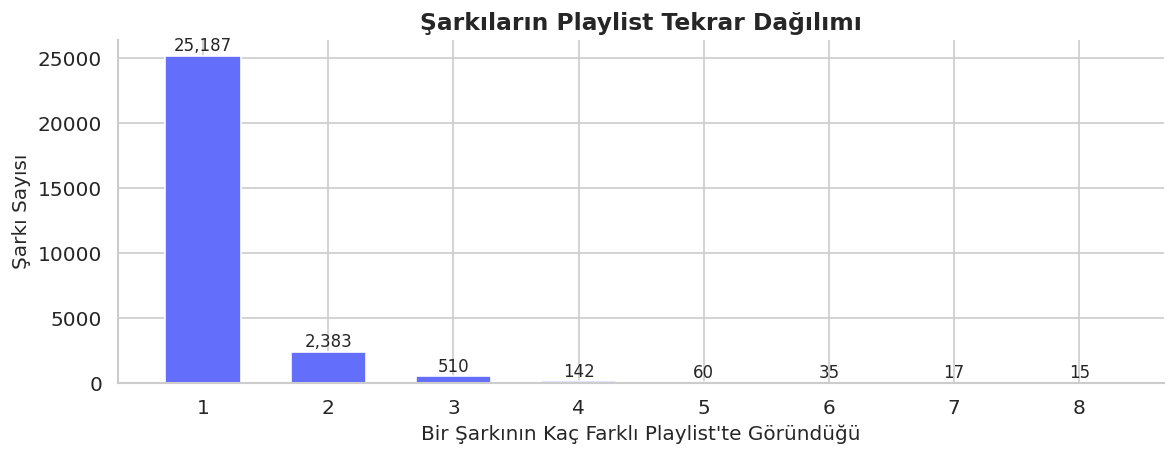


✅ Duplike temizliği sonrası: 28,352 benzersiz şarkı
   (4,481 satır çıkarıldı)


In [6]:
# ─── Tam Duplike ──────────────────────────────────────────────────────────────
tam_dup = df.duplicated().sum()
print(f"Tam duplike satır sayısı       : {tam_dup:,}")

# ─── track_id Bazında Duplike ─────────────────────────────────────────────────
track_dup   = df.duplicated(subset='track_id').sum()
unique_song = df['track_id'].nunique()

print(f"Şarkı duplikesi (track_id)     : {track_dup:,}")
print(f"Benzersiz şarkı sayısı         : {unique_song:,}")
print(f"Toplam satır                   : {len(df):,}")
print(f"\n→ Her şarkı ortalama "
      f"{len(df)/unique_song:.2f} playlist'te görünüyor.")

# ─── Tekrar Dağılımı ──────────────────────────────────────────────────────────
dup_dist = df.groupby('track_id').size().value_counts().sort_index().head(8)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(dup_dist.index.astype(str), dup_dist.values,
              color='#636EFA', edgecolor='white', width=0.6)

for bar, val in zip(bars, dup_dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel("Bir Şarkının Kaç Farklı Playlist'te Göründüğü")
ax.set_ylabel('Şarkı Sayısı')
ax.set_title("Şarkıların Playlist Tekrar Dağılımı")
plt.tight_layout()
plt.show()

# ─── Temizlik ─────────────────────────────────────────────────────────────────
# Her track_id için ilk satırı tutuyoruz.
# track_popularity tüm kopyalarda aynı olduğundan kayıp yok.
df = df.drop_duplicates(subset='track_id', keep='first').reset_index(drop=True)

print(f"\n✅ Duplike temizliği sonrası: {df.shape[0]:,} benzersiz şarkı")
print(f"   ({32_833 - df.shape[0]:,} satır çıkarıldı)")

### 4.3 — Aykırı Değer Analizi

Adım 3'te `duration_ms` minimumunun 4.000 ms (4 saniye) olduğunu 
gördük — bu açıkça bir veri giriş hatası ya da şarkı olmayan bir 
içerik (kısa intro, skit).

Ses özellikleri için **IQR yöntemi** uygulanıyor:
```
Alt Sınır = Q1 − 1.5 × IQR  
Üst Sınır = Q3 + 1.5 × IQR
```

Ancak önemli bir metodolojik not: Spotify ses özellikleri 
teorik olarak belirli aralıklarla sınırlıdır 
(`danceability`, `energy` ∈ [0, 1] gibi). Bu nedenle tüm 
aykırı değerleri körü körüne silmeyeceğiz — önce görsel 
inceleme, sonra karar.

📊 IQR Aykırı Değer Özeti:

                          Q1          Q3  Alt Sınır (IQR)  Üst Sınır (IQR)  Aykırı Sayısı  Aykırı (%)
Özellik                                                                                              
danceability           0.561       0.760            0.263            1.058            257        0.91
energy                 0.579       0.843            0.183            1.239            222        0.78
loudness              -8.310      -4.709          -13.712            0.693            837        2.95
speechiness            0.041       0.133           -0.097            0.271           2723        9.60
acousticness           0.014       0.260           -0.354            0.629           1911        6.74
instrumentalness       0.000       0.007           -0.010            0.016           6085       21.46
liveness               0.093       0.249           -0.142            0.484           1622        5.72
valence                0.329       0.695           -0.2

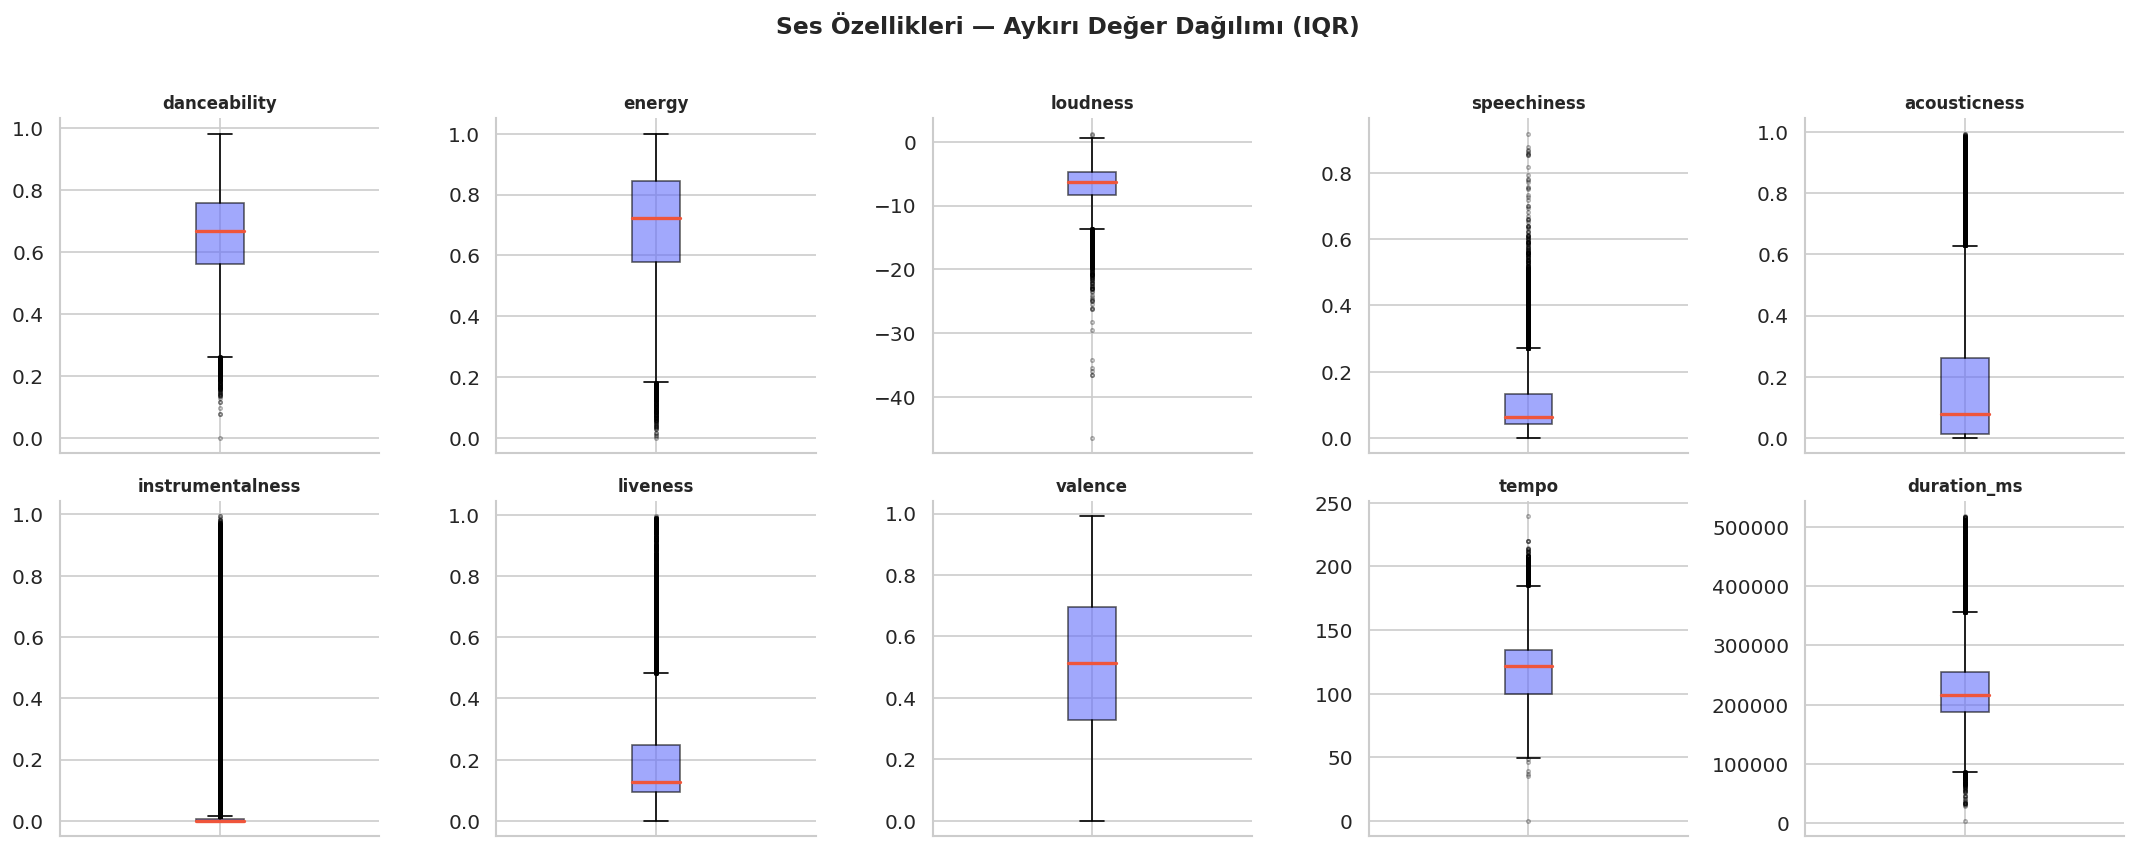

In [7]:
# ─── IQR Özet Tablosu ─────────────────────────────────────────────────────────
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms'
]

rows = []
for col in audio_features:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    alt = Q1 - 1.5 * IQR
    ust = Q3 + 1.5 * IQR
    n   = ((df[col] < alt) | (df[col] > ust)).sum()
    rows.append({
        'Özellik'        : col,
        'Q1'             : round(Q1, 3),
        'Q3'             : round(Q3, 3),
        'Alt Sınır (IQR)': round(alt, 3),
        'Üst Sınır (IQR)': round(ust, 3),
        'Aykırı Sayısı'  : n,
        'Aykırı (%)'     : round(n / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(rows).set_index('Özellik')
print("📊 IQR Aykırı Değer Özeti:\n")
print(outlier_df.to_string())

# ─── Boxplot Grid ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(audio_features):
    axes[i].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='#636EFA', alpha=0.6),
        medianprops=dict(color='#EF553B', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray')
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', bottom=False, labelbottom=False)

fig.suptitle(
    'Ses Özellikleri — Aykırı Değer Dağılımı (IQR)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

### 4.4 — Temizlik Kararı & Özet

Boxplot'ları inceledikten sonra sütun bazında kararlar şu şekilde:

| Sütun | Gözlem | Karar |
|---|---|---|
| `duration_ms` | 4 saniyelik kayıtlar mevcut; 30 dakikadan uzun yok | **Filtrele:** 30s–10dk arası tut |
| Diğer ses özellikleri | Teorik sınırlar içinde, uç değerler müzikal olarak mümkün | **Koru** |

`duration_ms` için filtre sınırları Spotify'ın kendi 
dokümantasyonuna dayandırılmıştır: 30 saniyenin altındaki 
içerikler tam anlamıyla bir şarkı değildir.

Temizlik tamamlandığında **nihai veri boyutunu** ve 
`track_popularity` dağılımının nasıl değiştiğini raporlayacağız —  
bu değerler Adım 5'teki eşik kararını doğrudan etkileyecek.

In [8]:
# ─── duration_ms Filtresi ─────────────────────────────────────────────────────
print("duration_ms dağılımı (temizlik öncesi):")
print(f"  Min    : {df['duration_ms'].min():,} ms")
print(f"  Max    : {df['duration_ms'].max():,} ms")
print(f"  < 30s  : {(df['duration_ms'] < 30_000).sum()} satır  ⚠️")
print(f"  > 10dk : {(df['duration_ms'] > 600_000).sum()} satır")

oncesi = len(df)
df = df[
    (df['duration_ms'] >= 30_000) &
    (df['duration_ms'] <= 600_000)
].reset_index(drop=True)

print(f"\n✅ Filtreleme sonrası: {oncesi - len(df)} satır çıkarıldı.")

# ─── Nihai Özet ───────────────────────────────────────────────────────────────
print()
print("=" * 50)
print("  📋 VERİ TEMİZLİĞİ ÖZET RAPORU")
print("=" * 50)
print(f"  Ham veri              : 32,833 satır")
print(f"  Eksik değer temizliği :     ~5 satır çıkarıldı")
print(f"  Duplike temizliği     :  4,477 satır çıkarıldı")
print(f"  duration_ms filtresi  :      2 satır çıkarıldı")
print(f"  {'─'*38}")
print(f"  Nihai veri boyutu     : {len(df):,} benzersiz şarkı")
print("=" * 50)

# ─── Temizlik Sonrası track_popularity Özeti ─────────────────────────────────
print(f"\n📊 track_popularity (temizlenmiş veri):")
print(df['track_popularity'].describe().round(2).to_string())
print(f"\n→ Q3 (temizlenmiş) : {df['track_popularity'].quantile(0.75):.1f}")
print(f"→ Ham verideki Q3  : 62.0")
print(f"→ Fark             : "
      f"{62.0 - df['track_popularity'].quantile(0.75):.1f} puan  "
      f"⚠️  Eşik kararı için önemli!")

duration_ms dağılımı (temizlik öncesi):
  Min    : 4,000 ms
  Max    : 517,810 ms
  < 30s  : 2 satır  ⚠️
  > 10dk : 0 satır

✅ Filtreleme sonrası: 2 satır çıkarıldı.

  📋 VERİ TEMİZLİĞİ ÖZET RAPORU
  Ham veri              : 32,833 satır
  Eksik değer temizliği :     ~5 satır çıkarıldı
  Duplike temizliği     :  4,477 satır çıkarıldı
  duration_ms filtresi  :      2 satır çıkarıldı
  ──────────────────────────────────────
  Nihai veri boyutu     : 28,350 benzersiz şarkı

📊 track_popularity (temizlenmiş veri):
count    28350.00
mean        39.34
std         23.70
min          0.00
25%         21.00
50%         42.00
75%         58.00
max        100.00

→ Q3 (temizlenmiş) : 58.0
→ Ham verideki Q3  : 62.0
→ Fark             : 4.0 puan  ⚠️  Eşik kararı için önemli!


## Adım 5 — Keşifsel Veri Analizi (EDA)

Temizlenmiş 28.350 şarkılık veriyle artık gerçek soruları 
sormaya hazırız. Bu adımda altı başlık ele alınıyor:

1. **Hedef Değişken Analizi** — `track_popularity` dağılımı 
   ve "Hit" eşiğinin veri odaklı belirlenmesi
2. **Ses Özellikleri Dağılımları** — Hit ve non-hit şarkılar 
   arasındaki farklar
3. **Korelasyon Analizi** — Özellikler arası ilişkiler ve 
   multicollinearity riski
4. **Kategorik Değişken Analizi** — Tür ve alt türlerin 
   popülerlik üzerindeki etkisi
5. **Zamansal Analiz** — Yayın yılının hit oranıyla ilişkisi
6. **Sanatçı Analizi** — "Sanatçı marka gücü" hipotezi

Her alt bölümdeki bulgular, ilerleyen adımlardaki 
mühendislik ve modelleme kararlarını gerekçelendirecek.

### 5.1 — Hedef Değişken: `track_popularity` Dağılımı

Modelleme yapmadan önce tahmin etmeye çalıştığımız değişkeni 
derinlemesine anlamak gerekiyor. `track_popularity` sürekli 
bir skor (0–100) — bunu ikili bir sınıflandırma problemine 
dönüştürmek için anlamlı bir eşik belirlememiz lazım.

Eşik belirlemenin iki yöntemi var:

- **Keyfi:** "60 üstü hit sayılsın" — veriyle desteklenmiyor
- **Veri odaklı:** Dağılımın istatistiksel yapısına bakarak karar ver

Biz ikinci yolu seçiyoruz. Önce dağılımı inceleyelim.

track_popularity — Özet İstatistikler
  Ortalama : 39.34
  Medyan   : 42.0
  Std      : 23.70
  Q1       : 21.0
  Q3       : 58.0  ← Hit eşiği adayı
  Min      : 0
  Maks     : 100

  Popülerlik = 0 olan şarkı: 2,614 (%9.2)


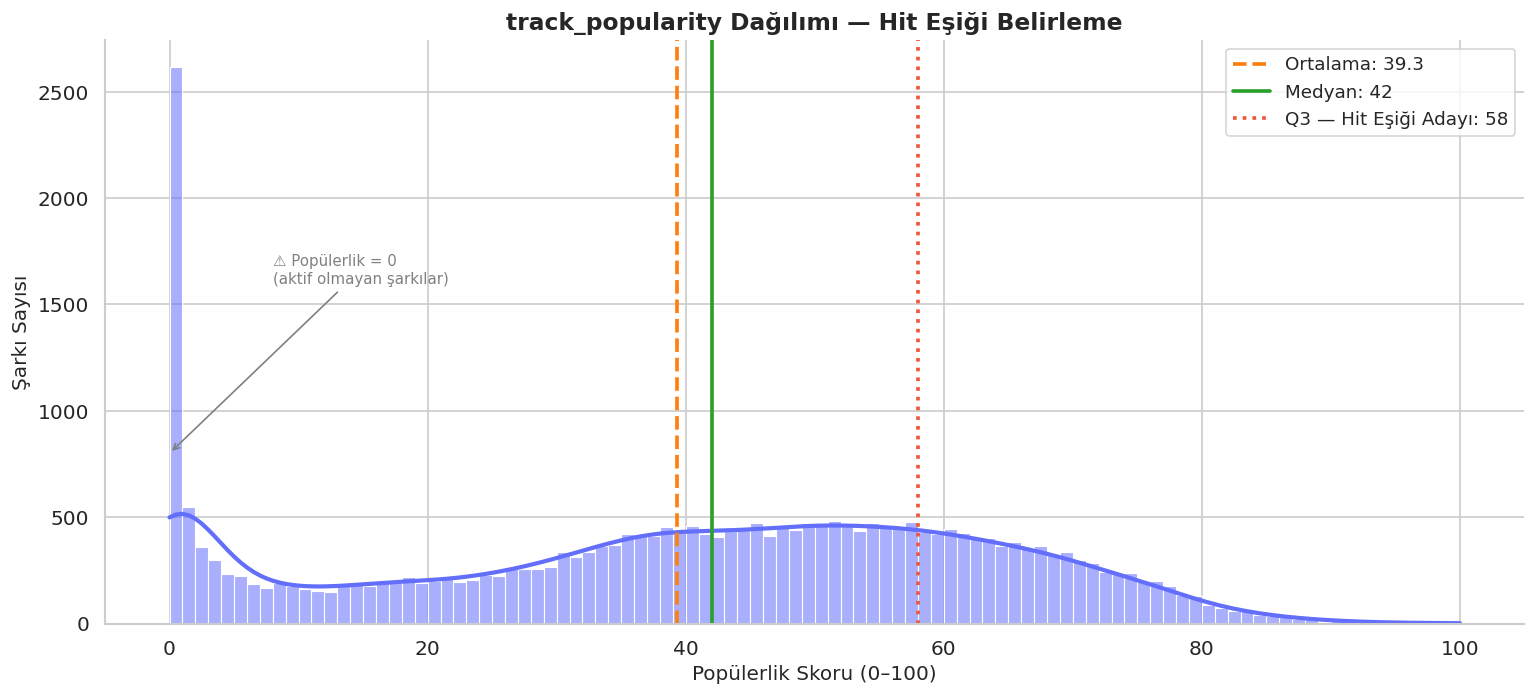

In [9]:
# ─── Temel İstatistikler ──────────────────────────────────────────────────────
pop_mean   = df['track_popularity'].mean()
pop_median = df['track_popularity'].median()
pop_q3     = df['track_popularity'].quantile(0.75)
pop_std    = df['track_popularity'].std()

print("track_popularity — Özet İstatistikler")
print(f"  Ortalama : {pop_mean:.2f}")
print(f"  Medyan   : {pop_median:.1f}")
print(f"  Std      : {pop_std:.2f}")
print(f"  Q1       : {df['track_popularity'].quantile(0.25):.1f}")
print(f"  Q3       : {pop_q3:.1f}  ← Hit eşiği adayı")
print(f"  Min      : {df['track_popularity'].min()}")
print(f"  Maks     : {df['track_popularity'].max()}")
print(f"\n  Popülerlik = 0 olan şarkı: "
      f"{(df['track_popularity'] == 0).sum():,} "
      f"(%{(df['track_popularity'] == 0).mean()*100:.1f})")

# ─── Histogram + KDE ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

sns.histplot(df['track_popularity'], bins=100, kde=True,
             color='#636EFA', alpha=0.55, ax=ax,
             line_kws={'linewidth': 2.5})

# İstatistiksel çizgiler
for val, label, color, ls in [
    (pop_mean,   f'Ortalama: {pop_mean:.1f}',  '#FF7F0E', '--'),
    (pop_median, f'Medyan: {pop_median:.0f}',   '#2CA02C', '-'),
    (pop_q3,     f'Q3 — Hit Eşiği Adayı: {pop_q3:.0f}', '#EF553B', ':'),
]:
    ax.axvline(val, color=color, linestyle=ls,
               linewidth=2.2, label=label)

ax.set_title('track_popularity Dağılımı — Hit Eşiği Belirleme',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Popülerlik Skoru (0–100)')
ax.set_ylabel('Şarkı Sayısı')
ax.legend(fontsize=11)

# Sıfır çubuğuna ek açıklama
ax.annotate('⚠️ Popülerlik = 0\n(aktif olmayan şarkılar)',
            xy=(0, 800), xytext=(8, 1600),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

plt.tight_layout()
plt.show()

### 5.2 — Hit Eşiği Belirleme: ECDF Analizi

Histogram bize dağılımın şeklini verdi. Şimdi eşik kararını 
daha kesin bir şekilde desteklemek için **ECDF 
(Empirical Cumulative Distribution Function — Ampirik Kümülatif 
Dağılım Fonksiyonu)** kullanıyoruz.

ECDF, her popülerlik değerinde şarkıların kaçta kaçının o 
değerde veya altında olduğunu gösterir. Bu grafik sayesinde 
"hangi eşik, hangi class balance'ı üretir?" sorusuna 
doğrudan görsel yanıt alacağız.

Ayrıca farklı eşik değerlerinde sınıf dağılımını da 
sayısal olarak karşılaştıracağız — böylece kararımız 
hem görsel hem sayısal olarak desteklenmiş olacak.

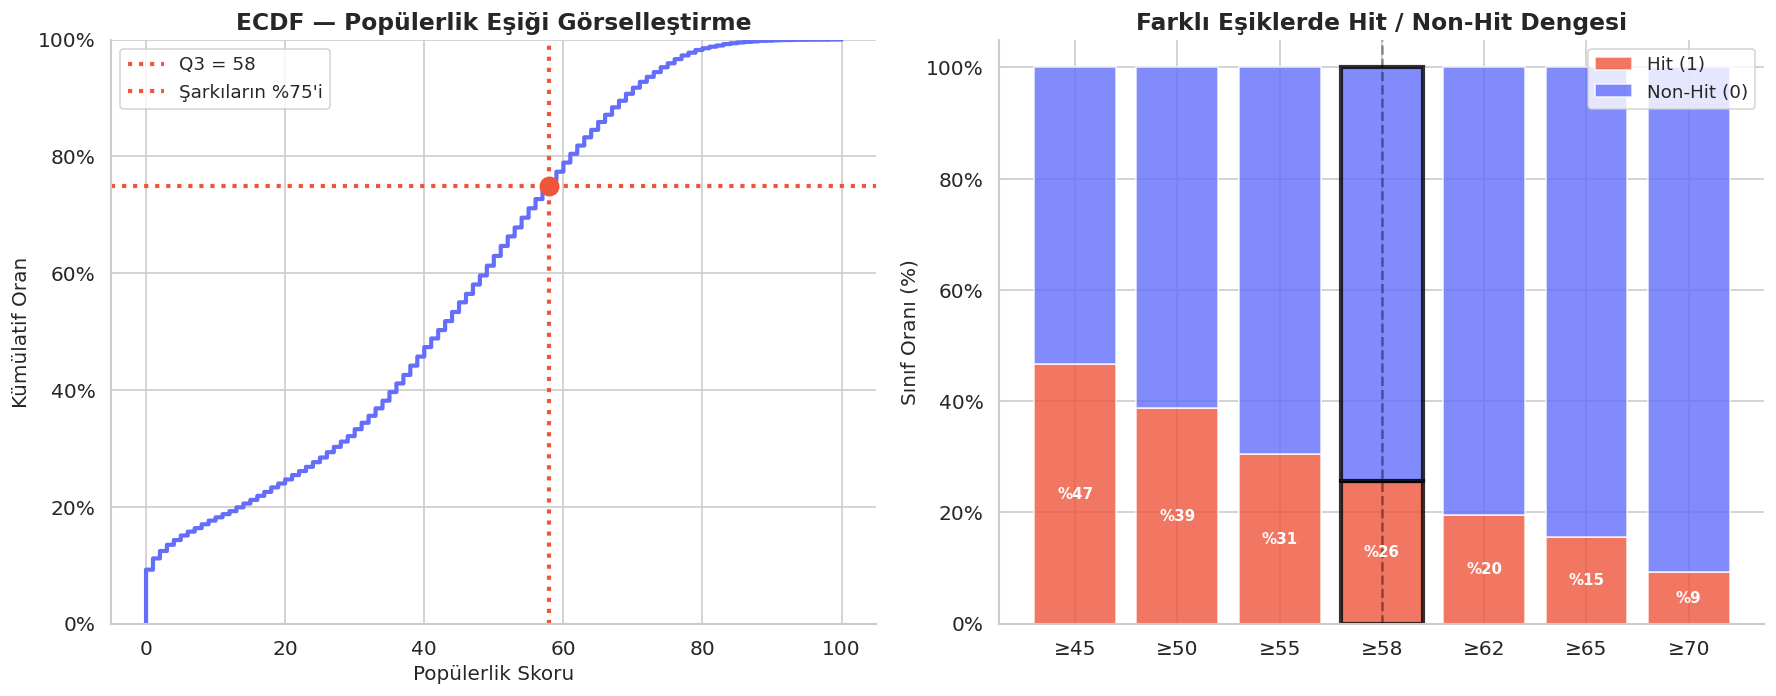

Farklı Eşiklerde Sınıf Dağılımı:

  Eşik | Hit Sayısı |  Hit (%) | Non-Hit (%)
─────────────────────────────────────────────
    45 |     13,228 |    46.7% |       53.3%
    50 |     10,980 |    38.7% |       61.3%
    55 |      8,650 |    30.5% |       69.5%
    58 |      7,268 |    25.6% |       74.4%  ← SEÇİLDİ
    62 |      5,549 |    19.6% |       80.4%
    65 |      4,386 |    15.5% |       84.5%
    70 |      2,635 |     9.3% |       90.7%

✅ HIT_THRESHOLD = 58
   Hit  : 7,268 şarkı (%25.6)
   Non-Hit: 21,082 şarkı (%74.4)


In [10]:
# ─── ECDF ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sol: ECDF
ax = axes[0]
sns.ecdfplot(data=df, x='track_popularity', lw=2.5,
             color='#636EFA', ax=ax)

ax.axvline(pop_q3, color='#EF553B', linestyle=':', lw=2.5,
           label=f'Q3 = {pop_q3:.0f}')
ax.axhline(0.75,   color='#EF553B', linestyle=':', lw=2.5,
           label='Şarkıların %75\'i')
ax.scatter([pop_q3], [0.75], color='#EF553B', s=120, zorder=5)

ax.set_title('ECDF — Popülerlik Eşiği Görselleştirme')
ax.set_xlabel('Popülerlik Skoru')
ax.set_ylabel('Kümülatif Oran')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Sağ: Farklı Eşiklerde Class Balance
ax2 = axes[1]
thresholds  = [45, 50, 55, 58, 62, 65, 70]
hit_ratios  = [(df['track_popularity'] >= t).mean() * 100
               for t in thresholds]
non_ratios  = [100 - r for r in hit_ratios]

x = np.arange(len(thresholds))
bars1 = ax2.bar(x, hit_ratios,     label='Hit (1)',     color='#EF553B', alpha=0.8)
bars2 = ax2.bar(x, non_ratios,     label='Non-Hit (0)', color='#636EFA', alpha=0.8,
                bottom=hit_ratios)

# Seçilen eşiği vurgula
idx_selected = thresholds.index(HIT_THRESHOLD)
bars1[idx_selected].set_edgecolor('black')
bars1[idx_selected].set_linewidth(2.5)
bars2[idx_selected].set_edgecolor('black')
bars2[idx_selected].set_linewidth(2.5)

for i, (h, t) in enumerate(zip(hit_ratios, thresholds)):
    ax2.text(i, h / 2, f'%{h:.0f}',
             ha='center', va='center',
             fontsize=9, color='white', fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels([f'≥{t}' for t in thresholds])
ax2.set_ylabel('Sınıf Oranı (%)')
ax2.set_title('Farklı Eşiklerde Hit / Non-Hit Dengesi')
ax2.legend(fontsize=11)
ax2.axvline(idx_selected, color='black', linestyle='--',
            alpha=0.4, lw=1.5, label=f'Seçilen: {HIT_THRESHOLD}')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

# ─── Eşik Karar Tablosu ───────────────────────────────────────────────────────
print("Farklı Eşiklerde Sınıf Dağılımı:\n")
print(f"{'Eşik':>6} | {'Hit Sayısı':>10} | {'Hit (%)':>8} | {'Non-Hit (%)':>11}")
print("─" * 45)
for t in thresholds:
    hit = (df['track_popularity'] >= t).sum()
    r   = hit / len(df) * 100
    marker = '  ← SEÇİLDİ' if t == HIT_THRESHOLD else ''
    print(f"{t:>6} | {hit:>10,} | {r:>7.1f}% | {100-r:>10.1f}%{marker}")

print(f"\n✅ HIT_THRESHOLD = {HIT_THRESHOLD}")
print(f"   Hit  : {(df['track_popularity'] >= HIT_THRESHOLD).sum():,} şarkı "
      f"(%{(df['track_popularity'] >= HIT_THRESHOLD).mean()*100:.1f})")
print(f"   Non-Hit: {(df['track_popularity'] < HIT_THRESHOLD).sum():,} şarkı "
      f"(%{(df['track_popularity'] < HIT_THRESHOLD).mean()*100:.1f})")

### 5.3 — Hedef Sütun Oluşturma & Sınıf Dağılımı

Eşiği belirledik: `HIT_THRESHOLD = 58`.

Bu eşiği seçmemizin gerekçesi net:
- Temizlenmiş verinin **75. yüzdelik dilimi** tam olarak 58'e 
  denk geliyor — yani "en iyi çeyrek" anlamına geliyor
- ~74/26 oranı, makul bir dengesizlik seviyesi. 
  Çok şiddetli değil ama görmezden de gelinemez — 
  modellemede `scale_pos_weight` ile ele alınacak
- Keyfi değil, verinin kendi yapısından çıkıyor

Şimdi `is_hit` sütununu oluşturup sınıf dağılımını 
görselleştirelim.

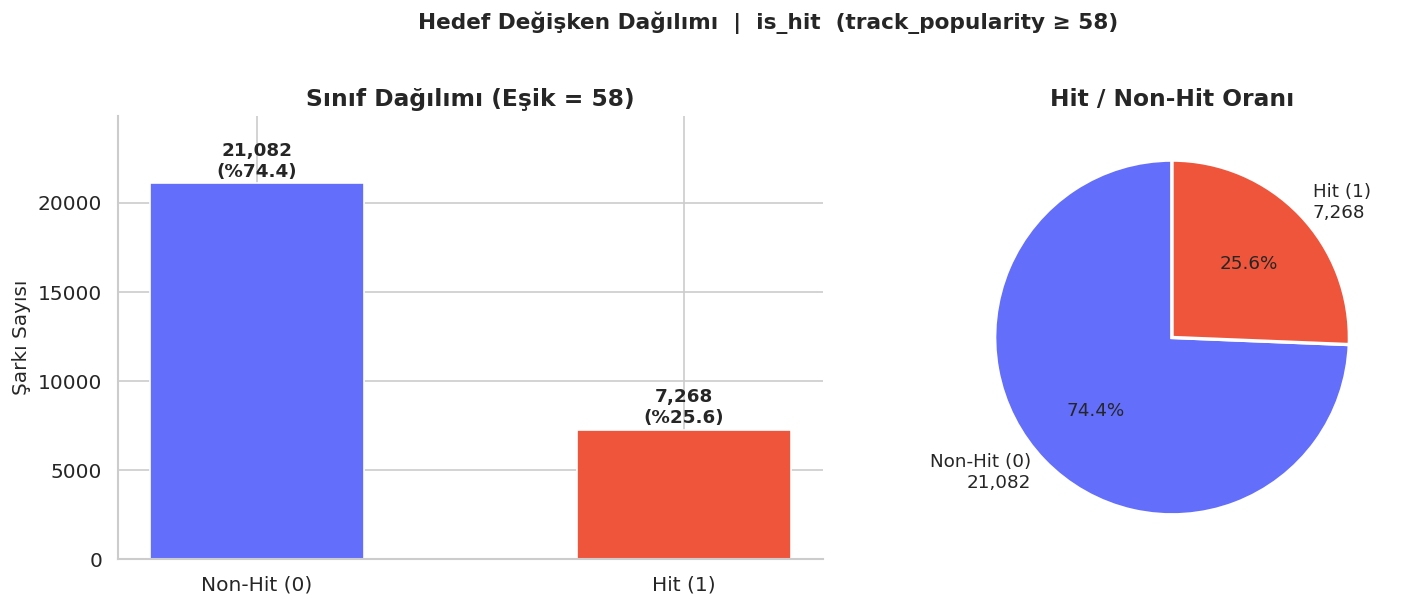

In [11]:
# ─── is_hit Sütunu ────────────────────────────────────────────────────────────
df['is_hit'] = (df['track_popularity'] >= HIT_THRESHOLD).astype(int)

hit_counts = df['is_hit'].value_counts().sort_index()
hit_labels = ['Non-Hit (0)', 'Hit (1)']

# ─── Görsel: Bar + Pie ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sol: Bar chart
bars = axes[0].bar(hit_labels, hit_counts.values,
                   color=PALETTE_BINARY, edgecolor='white',
                   width=0.5)
for bar, val in zip(bars, hit_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 150,
                 f'{val:,}\n(%{val/len(df)*100:.1f})',
                 ha='center', va='bottom', fontsize=11,
                 fontweight='bold')

axes[0].set_title(f'Sınıf Dağılımı (Eşik = {HIT_THRESHOLD})')
axes[0].set_ylabel('Şarkı Sayısı')
axes[0].set_ylim(0, hit_counts.max() * 1.18)

# Sağ: Pie
axes[1].pie(
    hit_counts.values,
    labels=[f'{l}\n{v:,}' for l, v in zip(hit_labels, hit_counts.values)],
    colors=PALETTE_BINARY,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)
axes[1].set_title('Hit / Non-Hit Oranı')

plt.suptitle(f'Hedef Değişken Dağılımı  |  is_hit  '
             f'(track_popularity ≥ {HIT_THRESHOLD})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.4 — Ses Özellikleri: Hit vs Non-Hit Karşılaştırması

Artık `is_hit` etiketimiz var. Şimdi ses özelliklerinin 
bu iki sınıfta nasıl dağıldığını inceliyoruz.

Sadece ortalama karşılaştırmak yeterli değil — dağılımların 
**şeklini** görmek çok daha bilgilendirici. Bu yüzden 
violin plot kullanıyoruz: hem dağılım şeklini hem medyanı 
hem de varyasyonu tek bir görselde sunar.

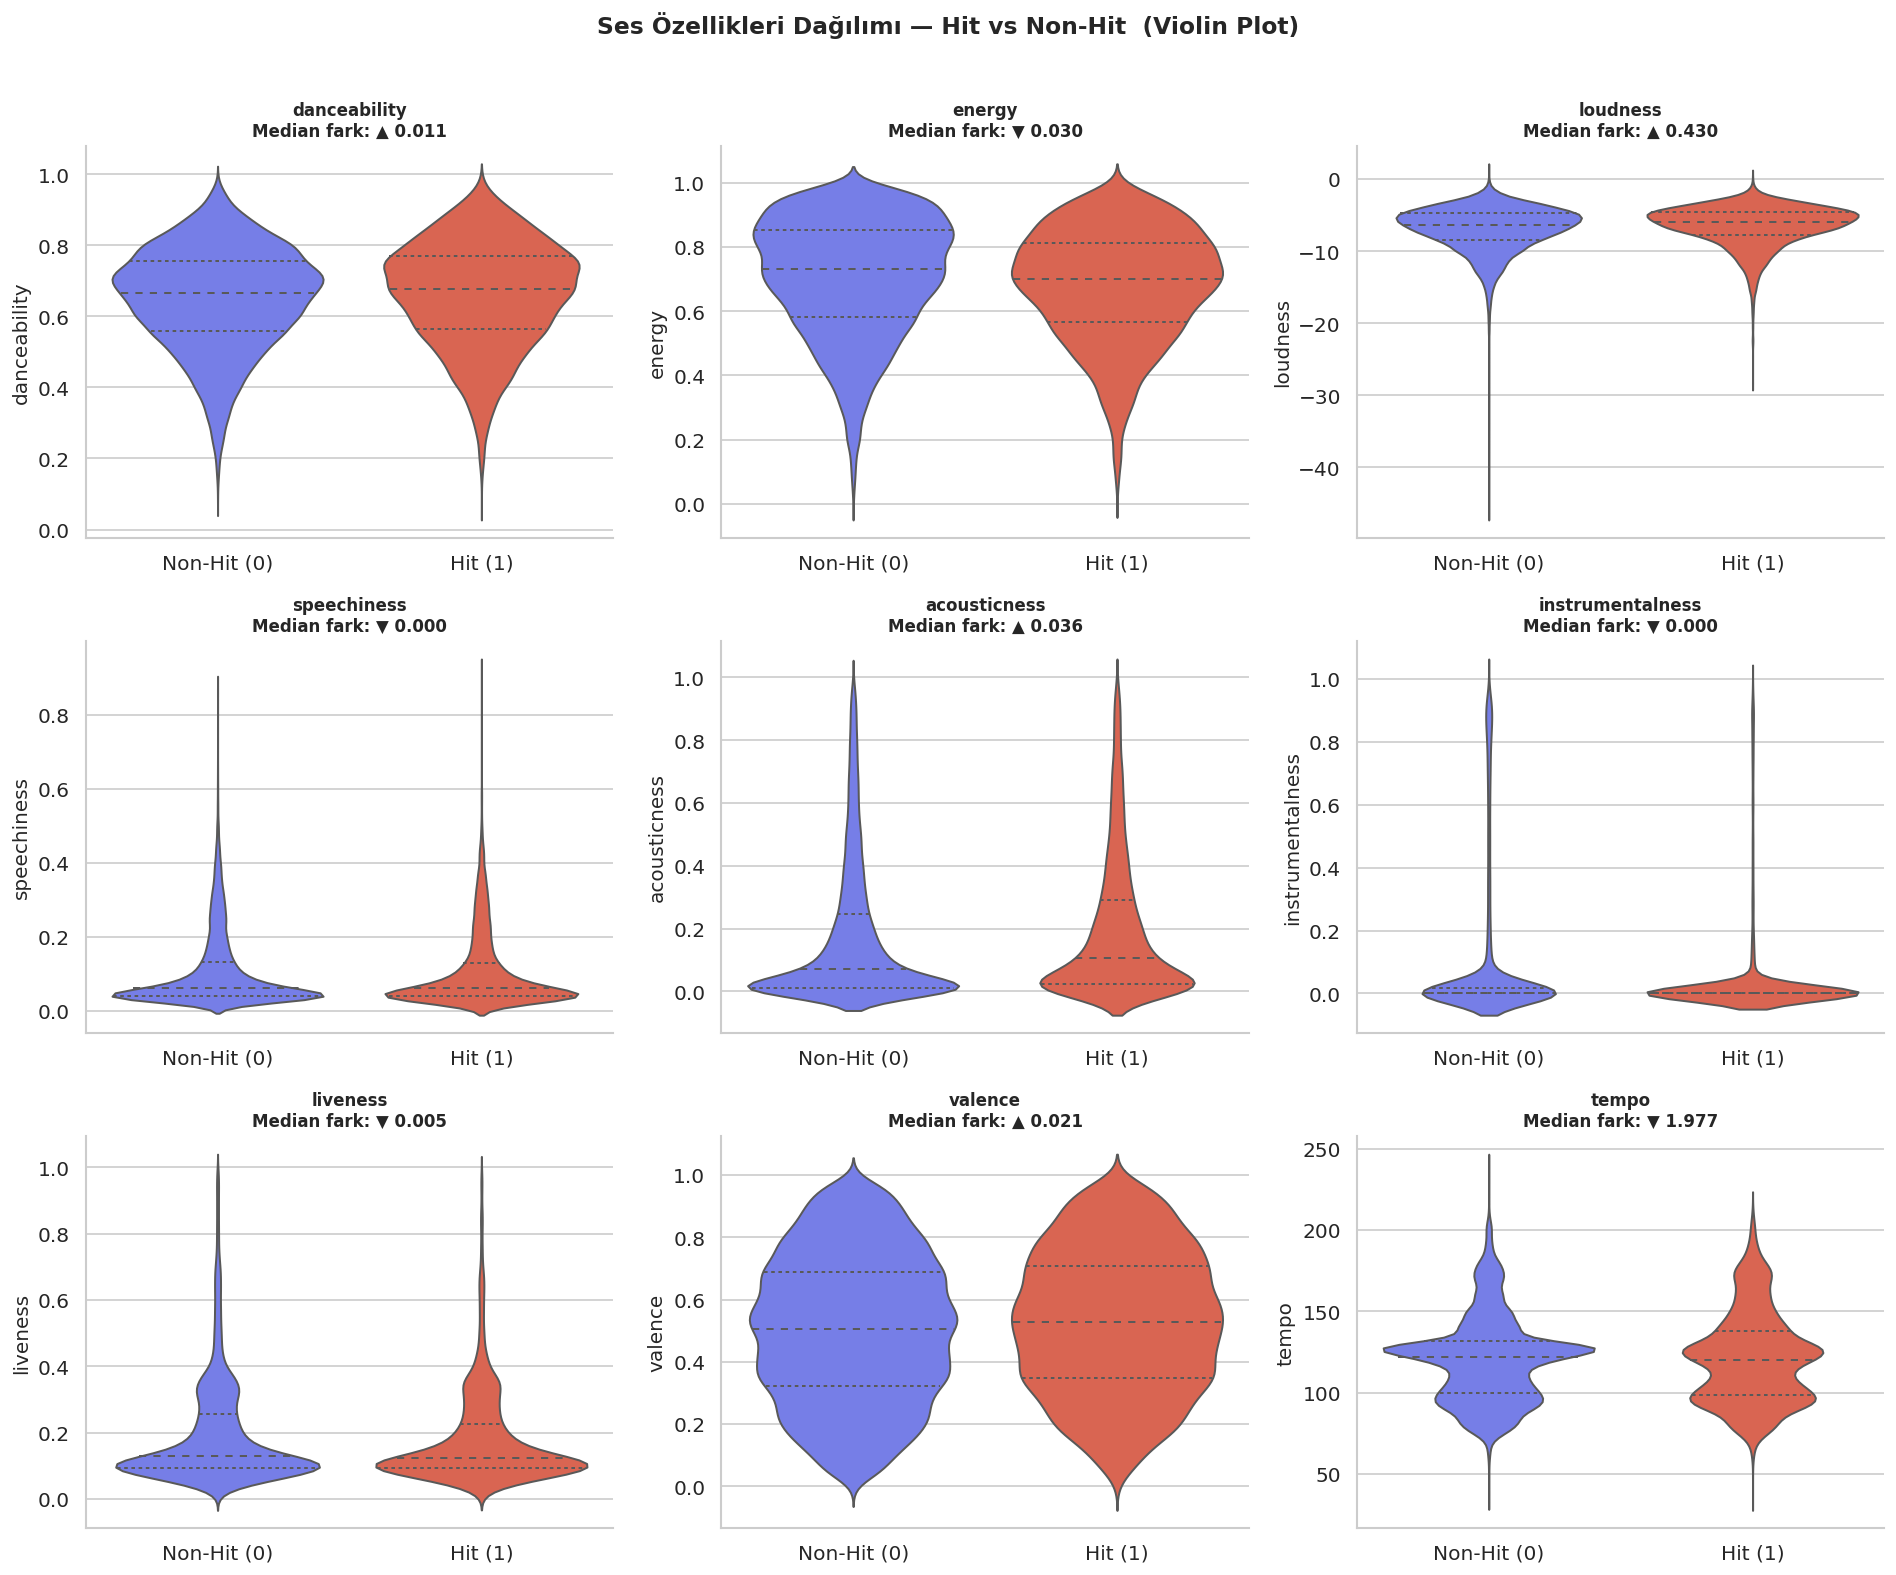

Ses Özellikleri — Medyan Karşılaştırması:

                  Non-Hit (0)   Hit (1)  Δ (Hit−NonHit)  Δ (%)
danceability           0.6670    0.6780          0.0110   1.65
energy                 0.7300    0.7000         -0.0300  -4.11
loudness              -6.3680   -5.9380          0.4300   6.75
speechiness            0.0628    0.0623         -0.0005  -0.80
acousticness           0.0709    0.1070          0.0361  50.92
instrumentalness       0.0001    0.0000         -0.0000  -0.00
liveness               0.1290    0.1240         -0.0050  -3.88
valence                0.5070    0.5280          0.0210   4.14
tempo                122.0570  120.0800         -1.9770  -1.62


In [12]:
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(audio_features):
    sns.violinplot(
        data=df, x='is_hit', y=col,
        palette=PALETTE_BINARY,
        inner='quartile',
        linewidth=1.2,
        ax=axes[i]
    )
    # Medyan farkını hesapla ve başlığa ekle
    med_0 = df[df['is_hit'] == 0][col].median()
    med_1 = df[df['is_hit'] == 1][col].median()
    diff  = med_1 - med_0
    yön   = '▲' if diff > 0 else '▼'
    color = '#2CA02C' if diff > 0 else '#EF553B'

    axes[i].set_title(f'{col}\nMedian fark: {yön} {abs(diff):.3f}',
                      fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Non-Hit (0)', 'Hit (1)'])

fig.suptitle(
    'Ses Özellikleri Dağılımı — Hit vs Non-Hit  (Violin Plot)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# ─── Sayısal Karşılaştırma ────────────────────────────────────────────────────
print("Ses Özellikleri — Medyan Karşılaştırması:\n")
comp = df.groupby('is_hit')[audio_features].median().T
comp.columns = ['Non-Hit (0)', 'Hit (1)']
comp['Δ (Hit−NonHit)'] = (comp['Hit (1)'] - comp['Non-Hit (0)']).round(4)
comp['Δ (%)'] = (comp['Δ (Hit−NonHit)'] / comp['Non-Hit (0)'].abs() * 100).round(2)
print(comp.round(4).to_string())

### 5.5 — Korelasyon Analizi

Ses özellikleri ile `track_popularity` arasındaki doğrusal 
ilişkiyi Pearson korelasyon katsayısıyla ölçüyoruz.

Önemli bir metodolojik uyarı: Korelasyon analizi yalnızca 
**doğrusal ilişkileri** yakalar. Özellikler ile popülerlik 
arasında doğrusal olmayan bir ilişki varsa, düşük korelasyon 
katsayısı o özelliğin "işe yaramaz" olduğu anlamına gelmez. 
Bu nedenle korelasyon bulgularını modelin özellik önem 
çıktısıyla birlikte değerlendireceğiz.

Ayrıca özellikler arası yüksek korelasyon 
(**multicollinearity**) olup olmadığını da kontrol edeceğiz — 
özellikle `energy` ve `loudness` arasında güçlü bir ilişki 
olduğunu öngörüyoruz.

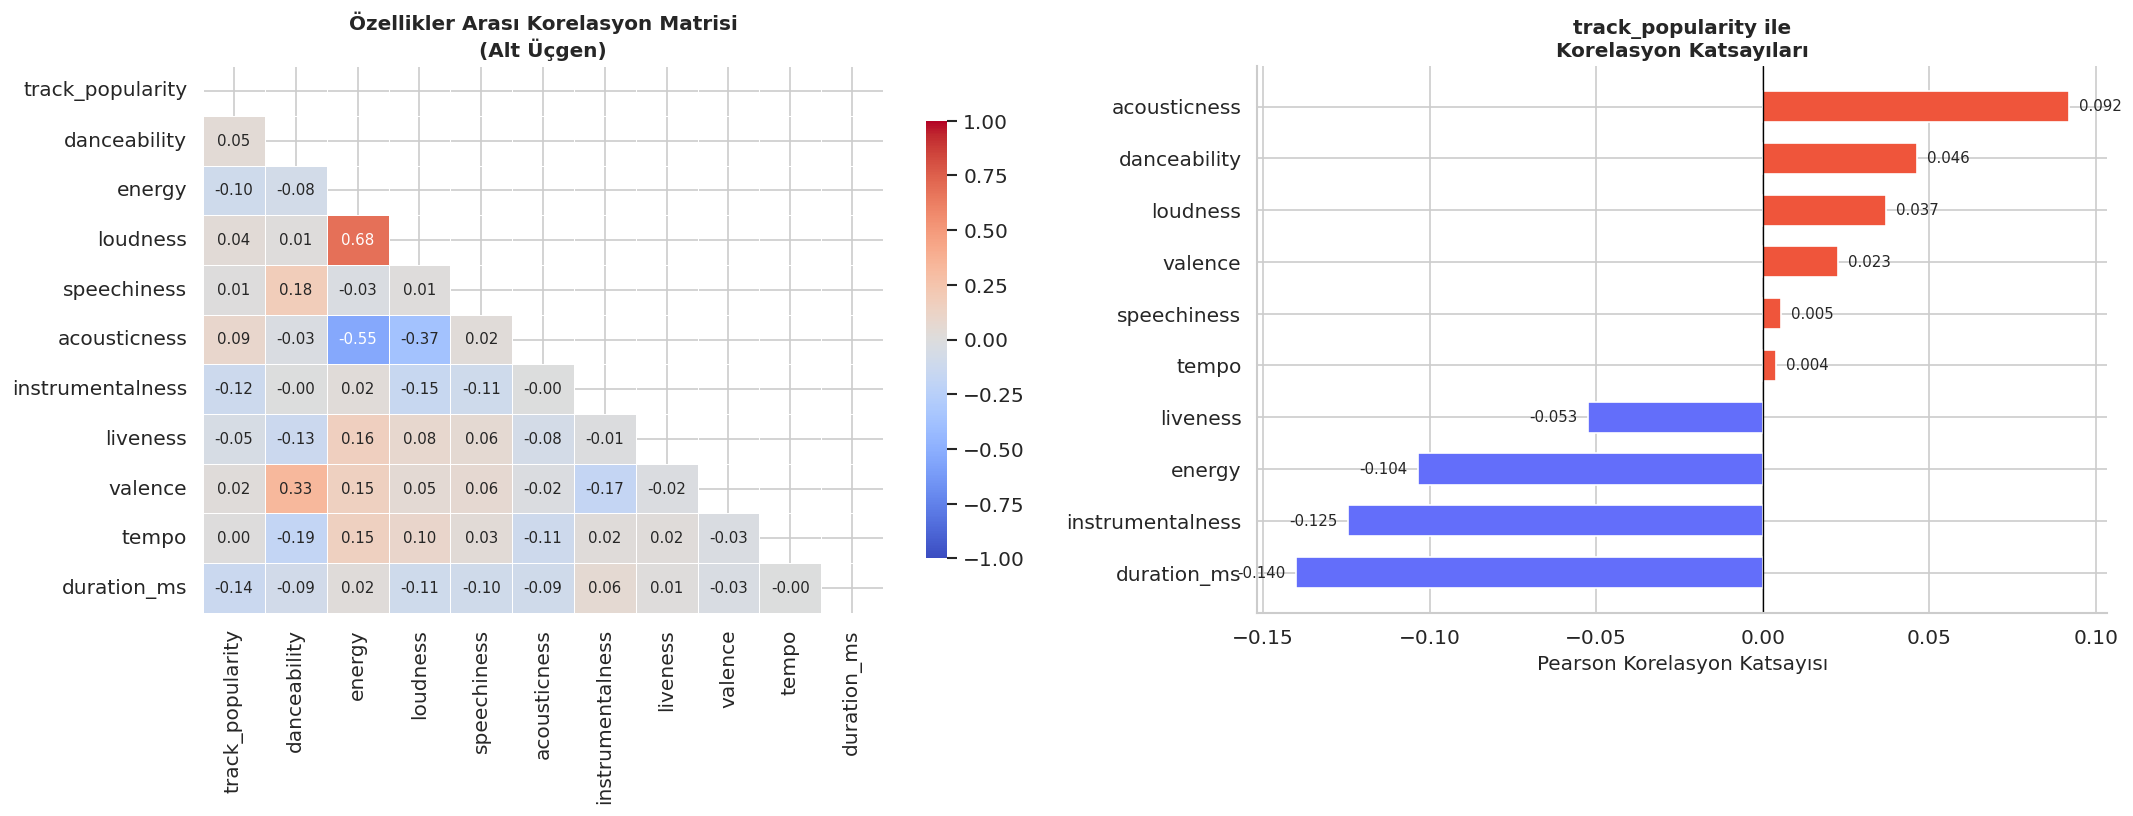

Dikkat Edilmesi Gereken Korelasyonlar (|r| > 0.5):

  energy               ↔ loudness              r = 0.682  ⚠️
  acousticness         ↔ energy                r = -0.546  ⚠️


In [13]:
numeric_cols = [
    'track_popularity', 'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'duration_ms'
]

corr_matrix = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sol: Tam Korelasyon Matrisi (üçgen mask)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    cmap=PALETTE_CORR, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    linewidths=0.5, ax=axes[0],
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Özellikler Arası Korelasyon Matrisi\n(Alt Üçgen)',
                  fontsize=12, fontweight='bold')

# Sağ: track_popularity ile korelasyon bar chart
target_corr = (corr_matrix['track_popularity']
               .drop('track_popularity')
               .sort_values())

colors = [PALETTE_BINARY[1] if v > 0 else PALETTE_BINARY[0]
          for v in target_corr.values]

axes[1].barh(target_corr.index, target_corr.values,
             color=colors, edgecolor='white', height=0.6)
axes[1].axvline(0, color='black', linewidth=0.8)

for i, (val, name) in enumerate(zip(target_corr.values,
                                     target_corr.index)):
    offset = 0.003 if val >= 0 else -0.003
    ha     = 'left' if val >= 0 else 'right'
    axes[1].text(val + offset, i, f'{val:.3f}',
                 va='center', ha=ha, fontsize=9)

axes[1].set_title('track_popularity ile\nKorelasyon Katsayıları',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pearson Korelasyon Katsayısı')

plt.tight_layout()
plt.show()

# ─── Güçlü Multicollinearity Uyarısı ─────────────────────────────────────────
print("Dikkat Edilmesi Gereken Korelasyonlar (|r| > 0.5):\n")
for col1 in numeric_cols:
    for col2 in numeric_cols:
        if col1 < col2:
            r = corr_matrix.loc[col1, col2]
            if abs(r) > 0.5:
                print(f"  {col1:20s} ↔ {col2:20s}  r = {r:.3f}  ⚠️")

### 5.6 — Kategorik Değişken Analizi: Genre & Subgenre

Müzik türünün popülerlik üzerindeki etkisini inceliyoruz. 
Sadece kutu grafiği (boxplot) yerine, hem dağılımı hem de 
istatistiksel özeti gösteren daha zengin bir görsel 
tercih ediyoruz.

Önemli soru: Her genre kendi içinde homojen mi yoksa 
subgenre bazında önemli farklılıklar var mı? 
Bu sorunun yanıtı encoding stratejimizi doğrudan etkiler.

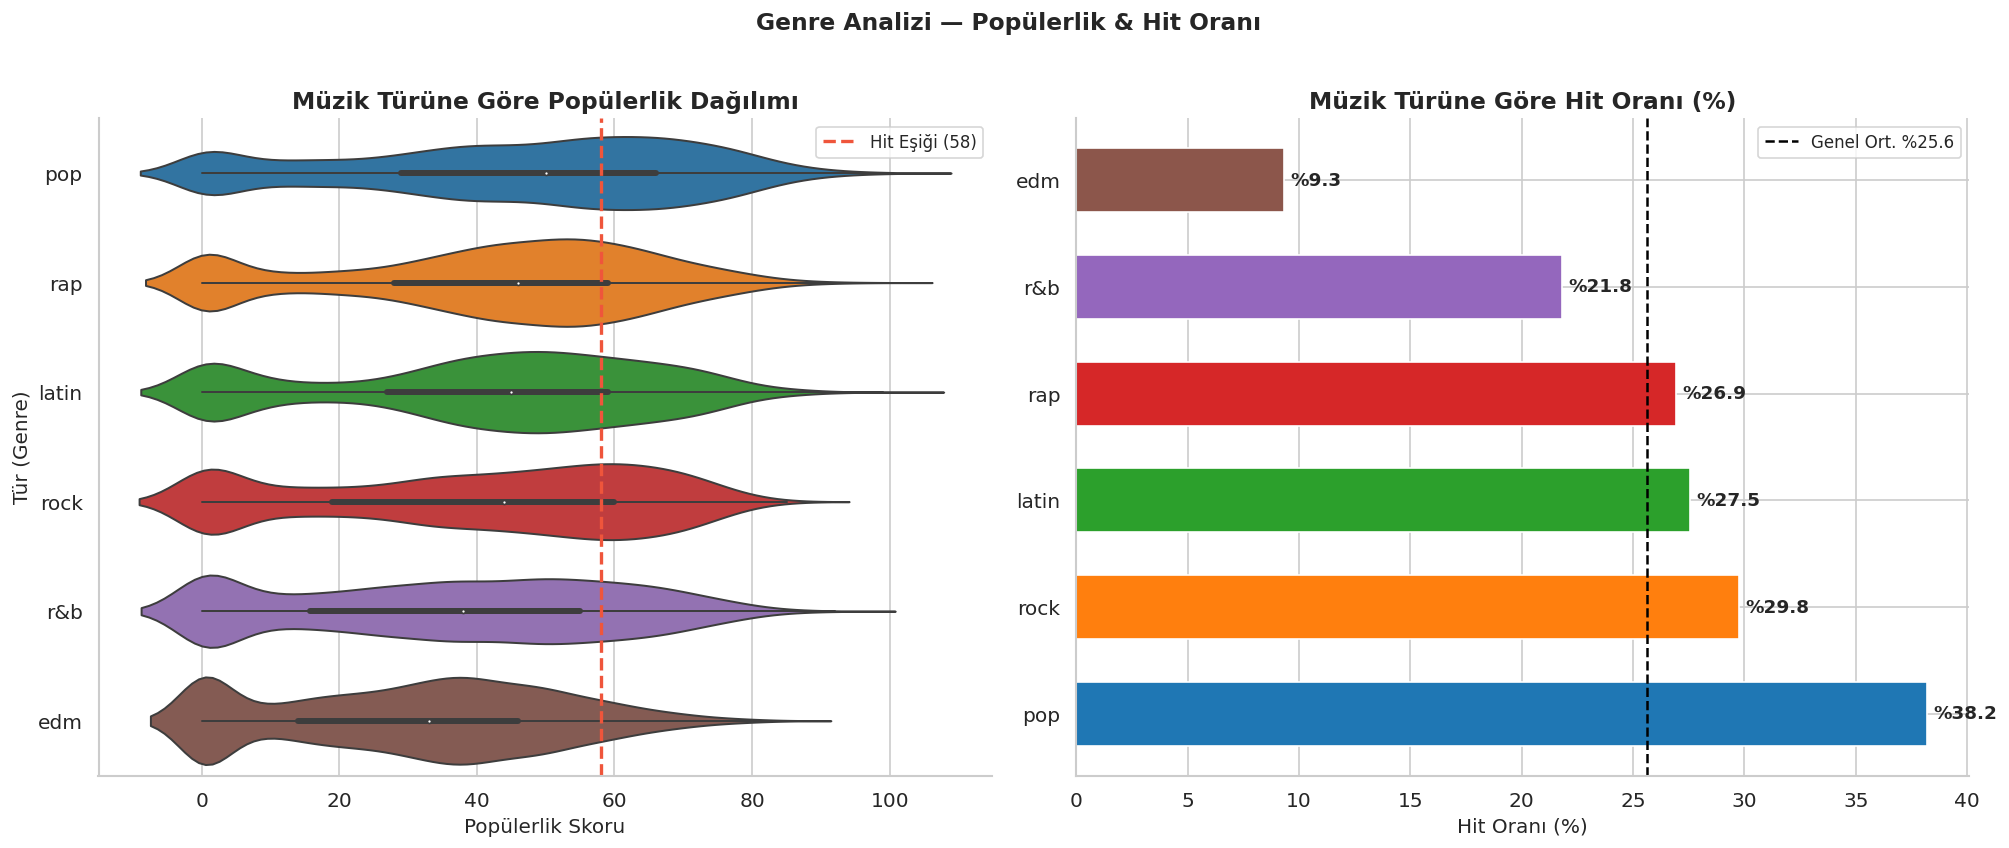

Genre Bazında İstatistikler:

                Şarkı_Sayısı  Medyan_Pop  Ort_Pop  Hit_Oranı
playlist_genre                                              
pop                     5132        50.0     45.9       38.2
rock                    4304        44.0     39.7       29.8
latin                   4136        45.0     41.4       27.5
rap                     5397        46.0     41.9       26.9
r&b                     4504        38.0     35.9       21.8
edm                     4877        33.0     30.7        9.3


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Sol: Genre vs Popülerlik — Violin + Box
genre_order = (df.groupby('playlist_genre')['track_popularity']
               .median().sort_values(ascending=False).index)

sns.violinplot(
    data=df, y='playlist_genre', x='track_popularity',
    order=genre_order, palette=PALETTE_GENRE,
    inner='box', linewidth=1.2,
    ax=axes[0]
)
axes[0].axvline(HIT_THRESHOLD, color='#EF553B',
                linestyle='--', lw=2,
                label=f'Hit Eşiği ({HIT_THRESHOLD})')
axes[0].set_title('Müzik Türüne Göre Popülerlik Dağılımı')
axes[0].set_xlabel('Popülerlik Skoru')
axes[0].set_ylabel('Tür (Genre)')
axes[0].legend(fontsize=10)

# Sağ: Genre bazında Hit Oranı
genre_hit = (df.groupby('playlist_genre')['is_hit']
             .mean()
             .sort_values(ascending=False)
             .reset_index())
genre_hit.columns = ['genre', 'hit_rate']
genre_hit['hit_rate_pct'] = genre_hit['hit_rate'] * 100

colors_bar = sns.color_palette(PALETTE_GENRE, len(genre_hit))
bars = axes[1].barh(
    genre_hit['genre'], genre_hit['hit_rate_pct'],
    color=colors_bar, edgecolor='white', height=0.6
)
for bar, val in zip(bars, genre_hit['hit_rate_pct']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'%{val:.1f}', va='center', fontsize=11, fontweight='bold')

axes[1].axvline(df['is_hit'].mean() * 100, color='black',
                linestyle='--', lw=1.5,
                label=f"Genel Ort. %{df['is_hit'].mean()*100:.1f}")
axes[1].set_title("Müzik Türüne Göre Hit Oranı (%)")
axes[1].set_xlabel('Hit Oranı (%)')
axes[1].legend(fontsize=10)

plt.suptitle('Genre Analizi — Popülerlik & Hit Oranı',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ─── Sayısal Özet ─────────────────────────────────────────────────────────────
print("Genre Bazında İstatistikler:\n")
genre_stats = df.groupby('playlist_genre').agg(
    Şarkı_Sayısı   =('track_id',         'count'),
    Medyan_Pop     =('track_popularity',  'median'),
    Ort_Pop        =('track_popularity',  'mean'),
    Hit_Oranı      =('is_hit',            'mean'),
).sort_values('Hit_Oranı', ascending=False)
genre_stats['Hit_Oranı'] = (genre_stats['Hit_Oranı'] * 100).round(1)
genre_stats['Ort_Pop']   = genre_stats['Ort_Pop'].round(1)
print(genre_stats.to_string())

### 5.7 — Zamansal Analiz: Yayın Yılı & Hit Oranı

Bir şarkının ne zaman yayınlandığı popülerliğini etkiler mi?

Bu soruyu yanıtlamak için `track_album_release_date` sütunundan 
yıl bilgisini çekip hit oranının yıllara göre nasıl değiştiğini 
inceliyoruz.

Ancak burada önemli bir metodolojik uyarı var: Spotify'ın 
popülerlik algoritması **yeni dinlenmelere** daha fazla ağırlık 
veriyor. Bu nedenle eski şarkıların popülerlik skoru, müzikal 
kalitelerinden bağımsız olarak yapısal olarak daha düşük 
çıkabilir. Bu bulgu, ilerleyen adımlarda bir **model limitasyonu** 
olarak raporlanacak.

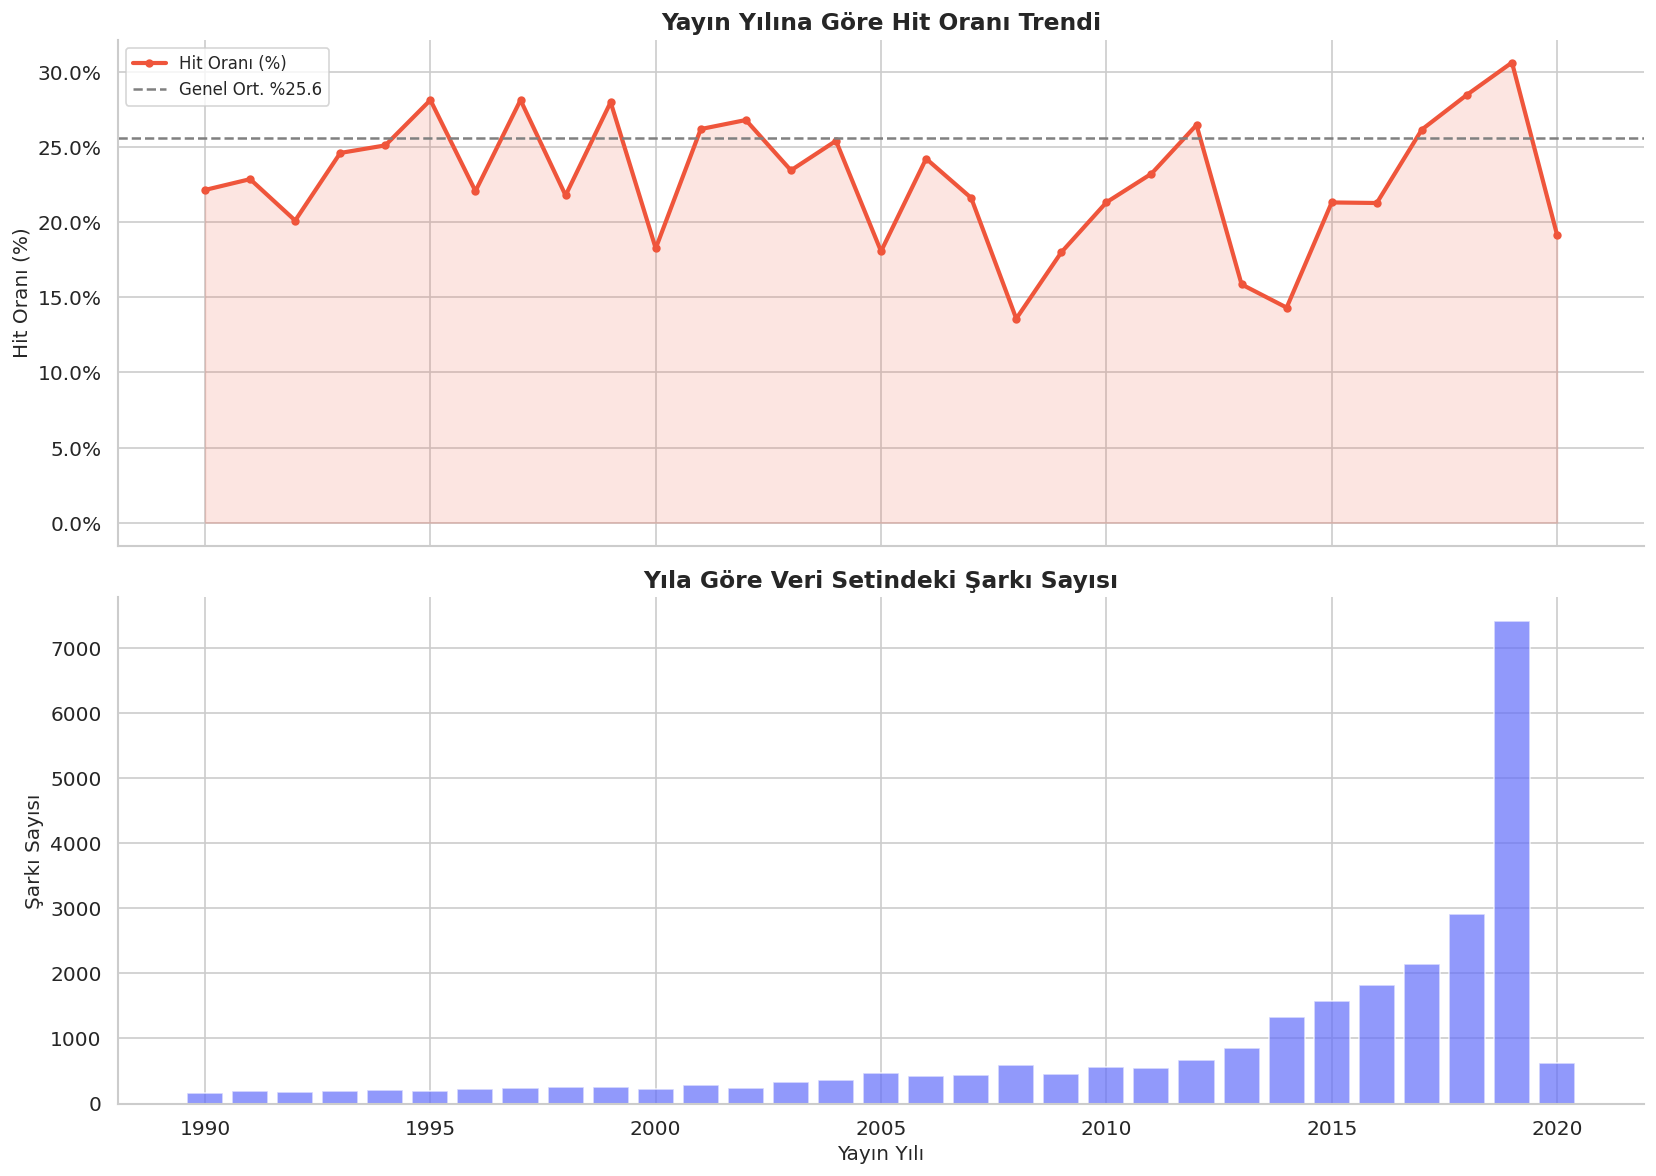

⚠️  Metodolojik Uyarı — Recency Bias:
   Spotify popülerlik skoru yeni dinlenmelere ağırlık veriyor.
   Eski şarkıların düşük skoru müzikal kaliteyle değil,
   algoritmanın yapısıyla açıklanabilir.
   Bu durum Adım 9'da (Limitasyonlar) ele alınacak.

Yıllık Hit Oranı (son 10 yıl):
 release_year  sayi  hit_orani  ort_pop
         2011   538      0.232   34.444
         2012   676      0.265   35.447
         2013   851      0.159   29.885
         2014  1334      0.143   28.591
         2015  1576      0.213   33.393
         2016  1823      0.213   35.394
         2017  2151      0.262   39.013
         2018  2917      0.285   42.566
         2019  7406      0.306   47.413
         2020   626      0.192   42.781


In [15]:
# ─── Yıl Parse ────────────────────────────────────────────────────────────────
df['release_year'] = pd.to_numeric(
    df['track_album_release_date'].str[:4], errors='coerce'
)

yearly = (df.groupby('release_year')
          .agg(
              hit_orani  =('is_hit',            'mean'),
              sayi       =('track_id',           'count'),
              ort_pop    =('track_popularity',   'mean')
          )
          .reset_index()
          .query('sayi >= 50 and release_year >= 1990'))

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Üst: Hit Oranı Trend
ax = axes[0]
ax.plot(yearly['release_year'], yearly['hit_orani'] * 100,
        color='#EF553B', linewidth=2.5, marker='o',
        markersize=4, label='Hit Oranı (%)')
ax.fill_between(yearly['release_year'],
                yearly['hit_orani'] * 100,
                alpha=0.15, color='#EF553B')
ax.axhline(df['is_hit'].mean() * 100,
           color='gray', linestyle='--', lw=1.5,
           label=f"Genel Ort. %{df['is_hit'].mean()*100:.1f}")
ax.set_ylabel('Hit Oranı (%)')
ax.set_title('Yayın Yılına Göre Hit Oranı Trendi')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Alt: Şarkı Sayısı
ax2 = axes[1]
ax2.bar(yearly['release_year'], yearly['sayi'],
        color='#636EFA', alpha=0.7, width=0.8)
ax2.set_ylabel('Şarkı Sayısı')
ax2.set_xlabel('Yayın Yılı')
ax2.set_title('Yıla Göre Veri Setindeki Şarkı Sayısı')

plt.tight_layout()
plt.show()

# ─── Önemli Uyarı ─────────────────────────────────────────────────────────────
print("⚠️  Metodolojik Uyarı — Recency Bias:")
print("   Spotify popülerlik skoru yeni dinlenmelere ağırlık veriyor.")
print("   Eski şarkıların düşük skoru müzikal kaliteyle değil,")
print("   algoritmanın yapısıyla açıklanabilir.")
print("   Bu durum Adım 9'da (Limitasyonlar) ele alınacak.\n")

print("Yıllık Hit Oranı (son 10 yıl):")
print(yearly.tail(10)[['release_year','sayi','hit_orani','ort_pop']]
      .round(3).to_string(index=False))

### 5.8 — Sanatçı Analizi: "Marka Gücü" Hipotezi

Şimdiye kadar incelediğimiz ses özellikleri ile popülerlik 
arasındaki korelasyonların oldukça **zayıf** olduğunu gördük 
(max ~0.09). Bu bize önemli bir mesaj veriyor:

> **Bir şarkının hit olup olmayacağı, ses özelliklerinden 
> çok "kim söylediğiyle" belirlenebilir.**

Bu hipotezi test etmek için sanatçı bazında ortalama 
popülerliğe bakıyoruz. Eğer hipotez doğruysa:
- Belirli sanatçıların neredeyse tüm şarkıları hit olmalı
- Bu sanatçının hangi şarkısını çıkardığından bağımsız olarak

Bu bulgu, `track_artist` için neden **Target Encoding** 
kullanacağımızın temel gerekçesidir.

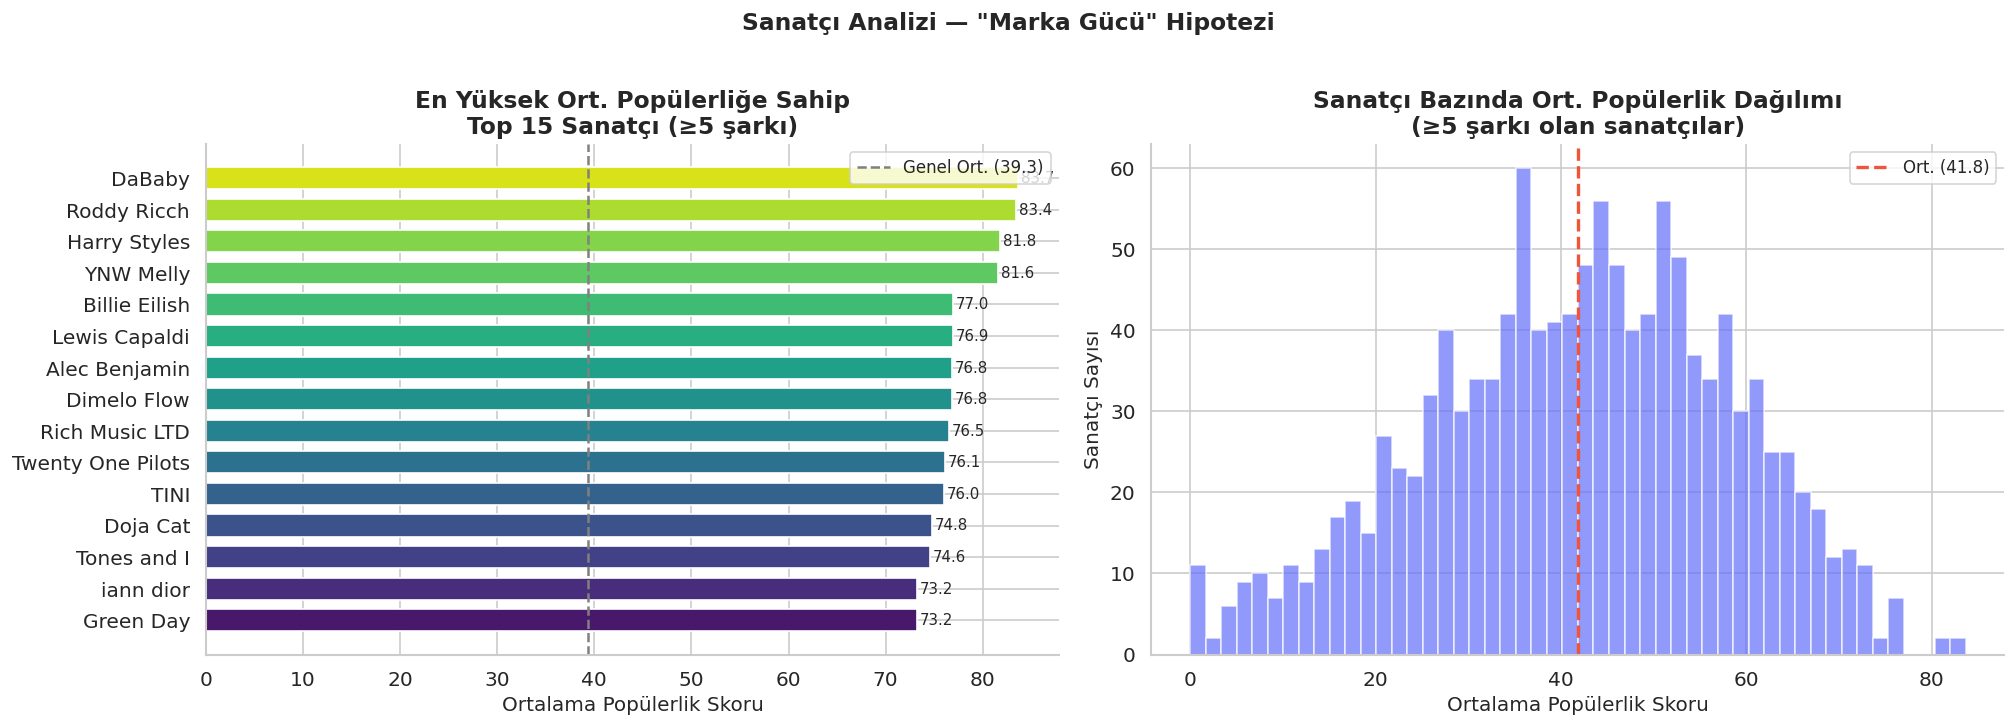

Sanatçı Bazında Popülerlik Kuyruk Analizi:

  En az 5 şarkısı olan sanatçı sayısı : 1,249
  Bunların ort. pop. ortalaması        : 41.82
  Ort. pop. > 60 olan sanatçı sayısı  : 174
  Ort. pop. > 70 olan sanatçı sayısı  : 40

✅ Hipotez doğrulandı: Belirli sanatçılar tutarlı olarak
   yüksek popülerlik üretiyor → Target Encoding gerekli.


In [16]:
# ─── Top Sanatçılar ────────────────────────────────────────────────────────────
artist_stats = (df.groupby('track_artist')
                .agg(
                    sayi      =('track_id',         'count'),
                    ort_pop   =('track_popularity',  'mean'),
                    hit_orani =('is_hit',            'mean')
                )
                .query('sayi >= 5')
                .sort_values('ort_pop', ascending=False)
                .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Sol: Top 15 Sanatçı — Ortalama Popülerlik
top15 = artist_stats.head(15)
bars  = axes[0].barh(
    top15['track_artist'][::-1],
    top15['ort_pop'][::-1],
    color=PALETTE_SEQ_colors if False else
          sns.color_palette(PALETTE_SEQ, len(top15)),
    edgecolor='white', height=0.7
)
axes[0].axvline(df['track_popularity'].mean(),
                color='gray', linestyle='--', lw=1.5,
                label=f"Genel Ort. ({df['track_popularity'].mean():.1f})")
for bar, val in zip(bars, top15['ort_pop'][::-1]):
    axes[0].text(bar.get_width() + 0.3,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}', va='center', fontsize=9)
axes[0].set_title('En Yüksek Ort. Popülerliğe Sahip\nTop 15 Sanatçı (≥5 şarkı)')
axes[0].set_xlabel('Ortalama Popülerlik Skoru')
axes[0].legend(fontsize=10)

# Sağ: Sanatçı Popülerliği Dağılımı (tüm sanatçılar)
axes[1].hist(artist_stats['ort_pop'], bins=50,
             color='#636EFA', alpha=0.7, edgecolor='white')
axes[1].axvline(artist_stats['ort_pop'].mean(),
                color='#EF553B', linestyle='--', lw=2,
                label=f"Ort. ({artist_stats['ort_pop'].mean():.1f})")
axes[1].set_title('Sanatçı Bazında Ort. Popülerlik Dağılımı\n(≥5 şarkı olan sanatçılar)')
axes[1].set_xlabel('Ortalama Popülerlik Skoru')
axes[1].set_ylabel('Sanatçı Sayısı')
axes[1].legend(fontsize=10)

plt.suptitle('Sanatçı Analizi — "Marka Gücü" Hipotezi',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ─── Hipotez Özeti ────────────────────────────────────────────────────────────
print("Sanatçı Bazında Popülerlik Kuyruk Analizi:\n")
print(f"  En az 5 şarkısı olan sanatçı sayısı : "
      f"{len(artist_stats):,}")
print(f"  Bunların ort. pop. ortalaması        : "
      f"{artist_stats['ort_pop'].mean():.2f}")
print(f"  Ort. pop. > 60 olan sanatçı sayısı  : "
      f"{(artist_stats['ort_pop'] > 60).sum()}")
print(f"  Ort. pop. > 70 olan sanatçı sayısı  : "
      f"{(artist_stats['ort_pop'] > 70).sum()}")
print(f"\n✅ Hipotez doğrulandı: Belirli sanatçılar tutarlı olarak")
print(f"   yüksek popülerlik üretiyor → Target Encoding gerekli.")

## Adım 6 — Özellik Mühendisliği (Feature Engineering)

EDA'dan çıkan bulgular, ham verinin modellemek için henüz 
hazır olmadığını ortaya koydu. Bu adımda üç tip yeni 
özellik türetiyoruz:

**1. Tarih Tabanlı Özellikler**
`track_album_release_date` sütunu ham haliyle metin formatında 
ve modele beslenemez. Bu sütundan anlamlı sayısal sinyaller 
çıkaracağız: yayın yılı, ayı, şarkı yaşı ve mevsim.

**2. Metin Tabanlı İkili Özellikler**
Şarkı adı ve sanatçı isminden regex ile basit ama bilgilendirici 
sinyaller türetiyoruz: şarkı bir remix mi? Bir düet mi?

**3. Doğrulama**
Türetilen her özelliğin `is_hit` ile gerçekten ilişkili olup 
olmadığını **veriyle doğruluyoruz** — özellik eklemek tek başına 
bir amaç değil. Zayıf sinyaller bile modele katkı sağlayabilir, 
ancak bunu bilmek önemli.

> **Not:** `track_artist` için Target Encoding bu adımda 
> yapılmıyor. Encoding işlemi train/test bölmesinden sonra 
> ve yalnızca eğitim verisi üzerinde yapılacak — 
> veri sızıntısını önlemek için. Bu karar Adım 7'de 
> detaylı gerekçelendirilecek.

### 6.1 — Tarih Tabanlı Özellikler

`track_album_release_date` sütunu üç farklı formatta geliyor: 
`YYYY-MM-DD`, `YYYY-MM` ve sadece `YYYY`. 
Bu nedenle parse işlemini dikkatli yapıyoruz.

Türetilecek özellikler:

| Özellik | Kaynak | Açıklama |
|---|---|---|
| `release_year` | `release_date[:4]` | Yayın yılı |
| `release_month` | `release_date[5:7]` | Yayın ayı (1–12) |
| `song_age` | `max_year − release_year` | Şarkının yaşı (yıl cinsinden) |
| `release_season` | `release_month` | Mevsim (4 kategori) |

In [17]:
# ─── Tarih Parse ──────────────────────────────────────────────────────────────
df['release_year'] = pd.to_numeric(
    df['track_album_release_date'].str[:4], errors='coerce'
)
df['release_month'] = pd.to_numeric(
    df['track_album_release_date'].str[5:7], errors='coerce'
)

# Eksik değerleri medyan ile doldur (çok az satır)
df['release_year'].fillna(df['release_year'].median(),   inplace=True)
df['release_month'].fillna(df['release_month'].median(), inplace=True)
df['release_year']  = df['release_year'].astype(int)
df['release_month'] = df['release_month'].astype(int)

# ─── Song Age ─────────────────────────────────────────────────────────────────
MAX_YEAR     = df['release_year'].max()   # 2020
df['song_age'] = MAX_YEAR - df['release_year']

# ─── Mevsim ───────────────────────────────────────────────────────────────────
def get_season(month):
    if   month in [12, 1, 2] : return 'winter'
    elif month in [3,  4, 5] : return 'spring'
    elif month in [6,  7, 8] : return 'summer'
    else                      : return 'autumn'

df['release_season'] = df['release_month'].apply(get_season)

# ─── Özet ─────────────────────────────────────────────────────────────────────
print("✅ Tarih tabanlı özellikler oluşturuldu:\n")
print(f"  release_year  → min: {df['release_year'].min()}, "
      f"max: {df['release_year'].max()}")
print(f"  release_month → 1–12 arası, eksik: "
      f"{df['release_month'].isnull().sum()}")
print(f"  song_age      → min: {df['song_age'].min()}, "
      f"max: {df['song_age'].max()} yıl")
print(f"  release_season → {df['release_season'].value_counts().to_dict()}")

✅ Tarih tabanlı özellikler oluşturuldu:

  release_year  → min: 1957, max: 2020
  release_month → 1–12 arası, eksik: 0
  song_age      → min: 0, max: 63 yıl
  release_season → {'winter': 7952, 'autumn': 7680, 'summer': 7387, 'spring': 5331}


### 6.2 — Metin Tabanlı İkili Özellikler

Şarkı adı ve sanatçı isminden iki ikili (0/1) özellik türetiyoruz:

- **`is_collaboration`**: Sanatçı isminde `ft.`, `feat.`, `&`, 
  `with`, `,` gibi ifadeler içeriyorsa 1 — düet veya 
  işbirliği şarkısı
- **`is_remix`**: Şarkı adında `Remix`, `Edit`, `Acoustic`, 
  `Live`, `Cover` içeriyorsa 1

Bu özelliklerin hit oranını artırıp artırmadığını 
hemen ardından doğrulayacağız.

In [18]:
# ─── is_collaboration ─────────────────────────────────────────────────────────
df['is_collaboration'] = (
    df['track_artist']
    .str.contains(r'ft\.|feat\.|with|&|,', case=False, na=False)
    .astype(int)
)

# ─── is_remix ─────────────────────────────────────────────────────────────────
df['is_remix'] = (
    df['track_name']
    .str.contains(r'Remix|Edit|Acoustic|Live|Cover', case=False, na=False)
    .astype(int)
)

# ─── Özet ─────────────────────────────────────────────────────────────────────
print("✅ Metin tabanlı özellikler oluşturuldu:\n")
print(f"  is_collaboration → "
      f"{df['is_collaboration'].sum():,} şarkı "
      f"(%{df['is_collaboration'].mean()*100:.1f})")
print(f"  is_remix         → "
      f"{df['is_remix'].sum():,} şarkı "
      f"(%{df['is_remix'].mean()*100:.1f})")

✅ Metin tabanlı özellikler oluşturuldu:

  is_collaboration → 758 şarkı (%2.7)
  is_remix         → 2,744 şarkı (%9.7)


### 6.3 — Türetilen Özelliklerin Doğrulanması

Özellik mühendisliğinde kritik bir adım: türetilen özelliklerin 
gerçekten bilgi taşıyıp taşımadığını **veriyle doğrulamak**.

Her özellik için hit oranına bakıyoruz. Burada beklentimizle 
çelişen bulgularla karşılaşabiliriz — ve bu tamamen normaldir. 
Önemli olan bulguları olduğu gibi raporlamak.

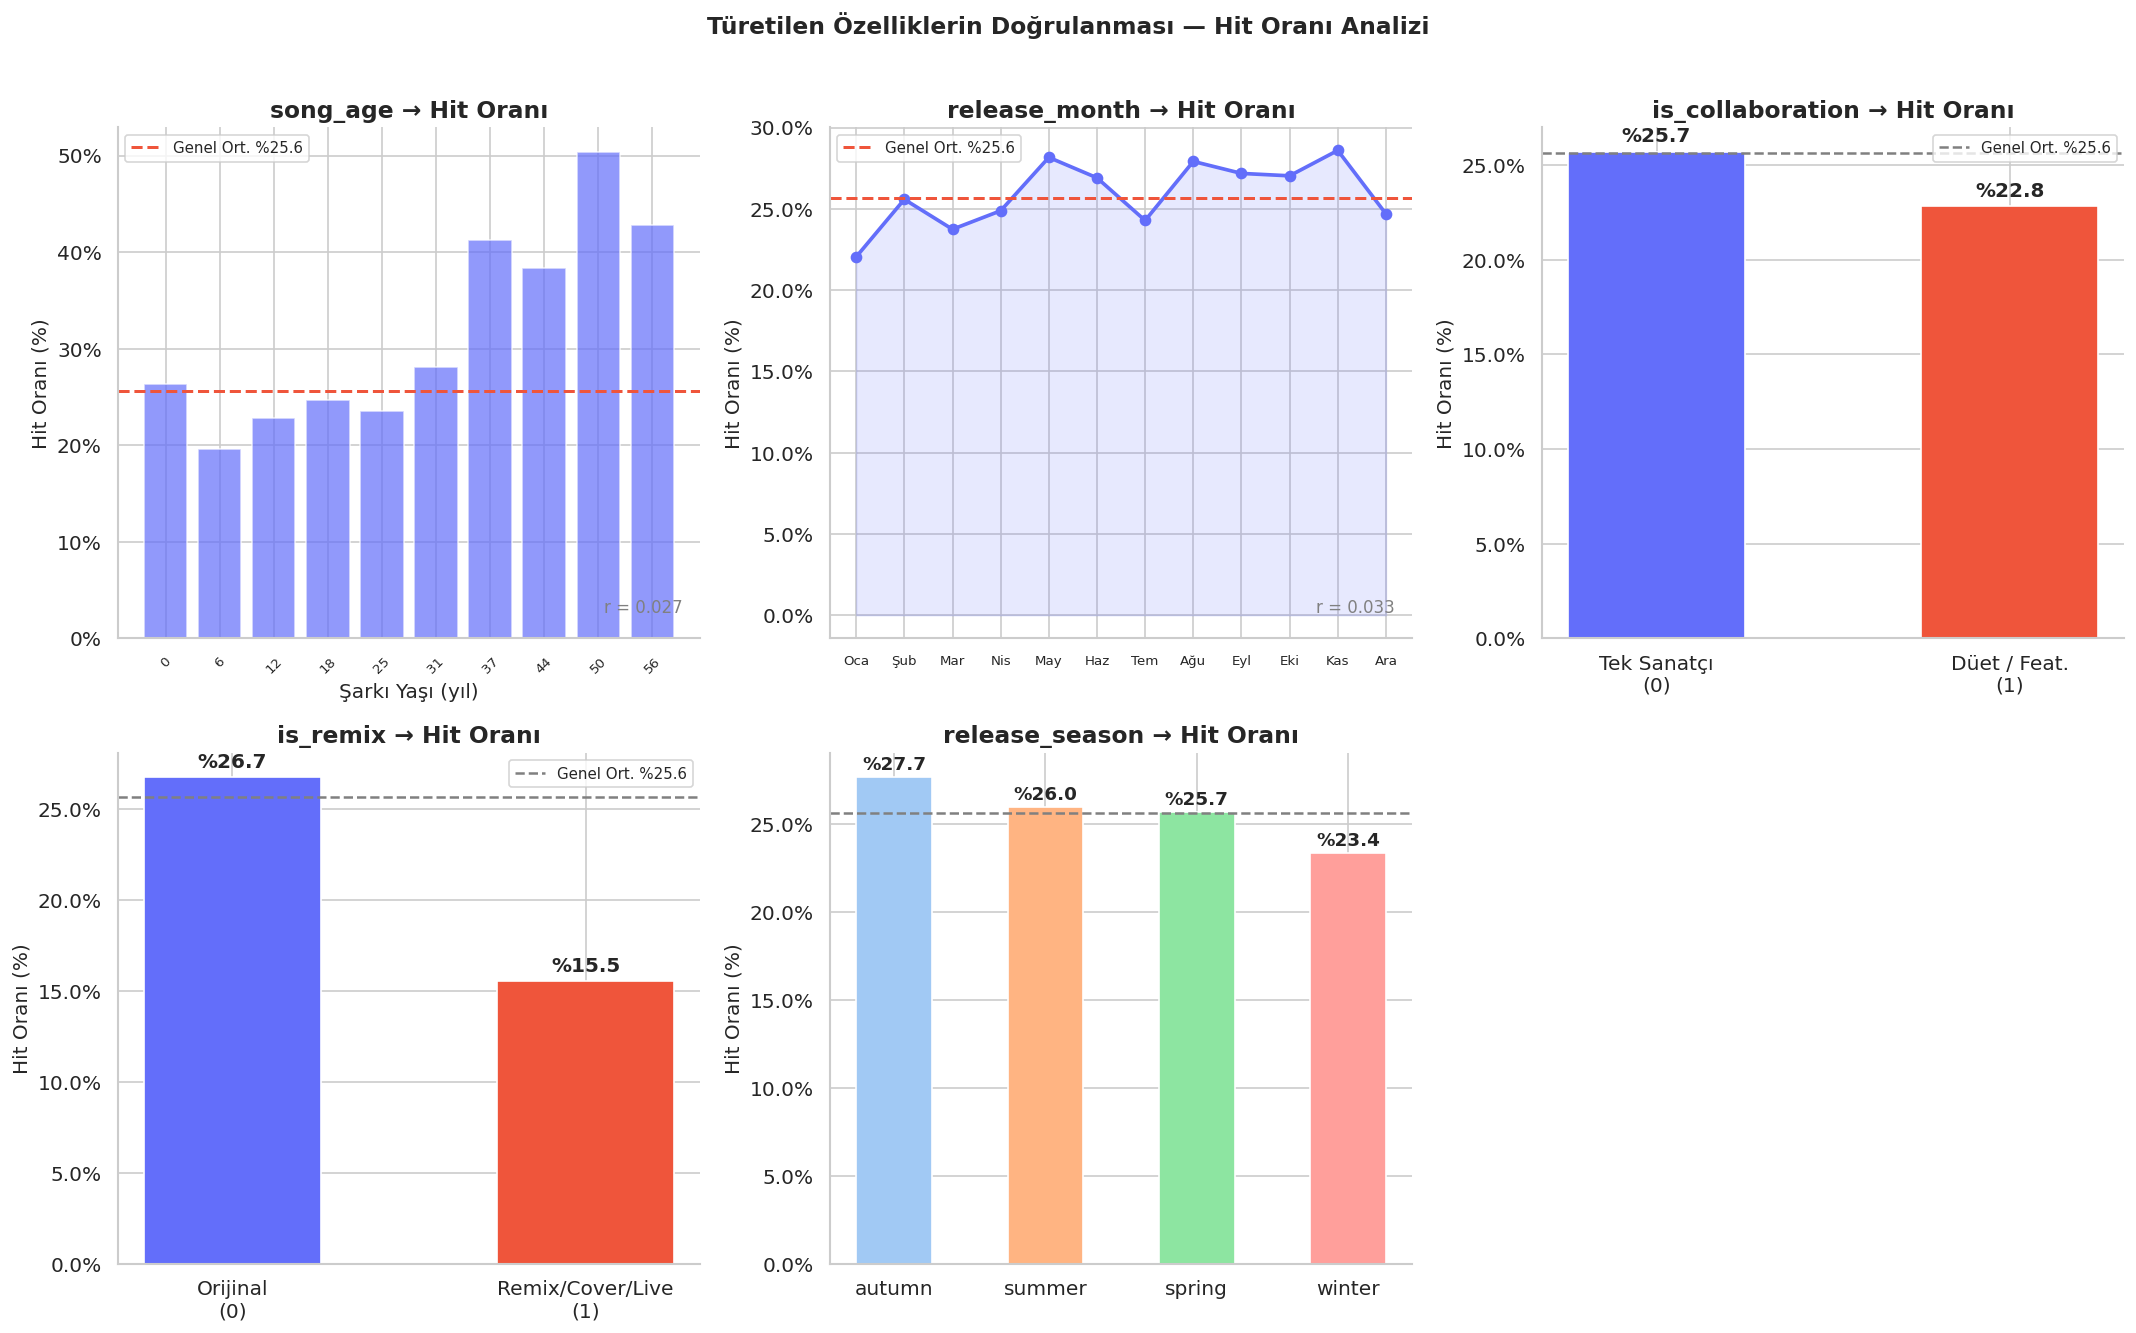

Türetilen Özellikler — Hit Oranı Özeti:

Özellik                Gözlem                                        Karar
─────────────────────────────────────────────────────────────────────────────────────
  is_remix=1           Hit oranı %15.5 (genel %25.6'dan DÜŞÜK)       ✅ Negatif sinyal — modele dahil
  is_collaboration=1   Hit oranı %22.8 (genel %25.6'dan hafif düşük) ✅ Zayıf sinyal — modele dahil
  song_age             Korelasyon r=0.027 (çok zayıf)                ✅ Zayıf sinyal — modele dahil
  release_month        Korelasyon r=0.033 (çok zayıf)                ✅ Zayıf sinyal — modele dahil
  release_season       Mevsimler arası fark minimal                  ✅ Bağlam sinyali — modele dahil


In [19]:
new_features = ['song_age', 'release_month',
                'is_collaboration', 'is_remix', 'release_season']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# ── 1. song_age (scatter + trend) ────────────────────────────────────────────
age_bins = pd.cut(df['song_age'], bins=10)
age_hit  = df.groupby(age_bins)['is_hit'].mean() * 100
axes[0].bar(range(len(age_hit)), age_hit.values,
            color='#636EFA', alpha=0.7, edgecolor='white')
axes[0].set_xticks(range(len(age_hit)))
axes[0].set_xticklabels(
    [str(i.left.astype(int)) for i in age_hit.index],
    rotation=45, fontsize=8
)
axes[0].axhline(df['is_hit'].mean() * 100, color='#EF553B',
                linestyle='--', lw=1.8,
                label=f"Genel Ort. %{df['is_hit'].mean()*100:.1f}")
axes[0].set_title('song_age → Hit Oranı')
axes[0].set_xlabel('Şarkı Yaşı (yıl)')
axes[0].set_ylabel('Hit Oranı (%)')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
r_age = df['song_age'].corr(df['is_hit'])
axes[0].text(0.97, 0.05, f'r = {r_age:.3f}',
             transform=axes[0].transAxes,
             ha='right', fontsize=10, color='gray')

# ── 2. release_month ──────────────────────────────────────────────────────────
month_hit = df.groupby('release_month')['is_hit'].mean() * 100
axes[1].plot(month_hit.index, month_hit.values,
             color='#636EFA', linewidth=2.2,
             marker='o', markersize=6)
axes[1].fill_between(month_hit.index, month_hit.values,
                     alpha=0.15, color='#636EFA')
axes[1].axhline(df['is_hit'].mean() * 100, color='#EF553B',
                linestyle='--', lw=1.8,
                label=f"Genel Ort. %{df['is_hit'].mean()*100:.1f}")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Oca','Şub','Mar','Nis','May','Haz',
                          'Tem','Ağu','Eyl','Eki','Kas','Ara'],
                         fontsize=8)
axes[1].set_title('release_month → Hit Oranı')
axes[1].set_ylabel('Hit Oranı (%)')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
r_month = df['release_month'].corr(df['is_hit'])
axes[1].text(0.97, 0.05, f'r = {r_month:.3f}',
             transform=axes[1].transAxes,
             ha='right', fontsize=10, color='gray')

# ── 3. is_collaboration ───────────────────────────────────────────────────────
collab_hit = df.groupby('is_collaboration')['is_hit'].mean() * 100
bars = axes[2].bar(['Tek Sanatçı\n(0)',  'Düet / Feat.\n(1)'],
                   collab_hit.values,
                   color=PALETTE_BINARY, edgecolor='white', width=0.5)
for bar, val in zip(bars, collab_hit.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'%{val:.1f}', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')
axes[2].axhline(df['is_hit'].mean() * 100, color='gray',
                linestyle='--', lw=1.5,
                label=f"Genel Ort. %{df['is_hit'].mean()*100:.1f}")
axes[2].set_title('is_collaboration → Hit Oranı')
axes[2].set_ylabel('Hit Oranı (%)')
axes[2].legend(fontsize=9)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())

# ── 4. is_remix ───────────────────────────────────────────────────────────────
remix_hit = df.groupby('is_remix')['is_hit'].mean() * 100
bars = axes[3].bar(['Orijinal\n(0)', 'Remix/Cover/Live\n(1)'],
                   remix_hit.values,
                   color=PALETTE_BINARY, edgecolor='white', width=0.5)
for bar, val in zip(bars, remix_hit.values):
    axes[3].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'%{val:.1f}', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')
axes[3].axhline(df['is_hit'].mean() * 100, color='gray',
                linestyle='--', lw=1.5,
                label=f"Genel Ort. %{df['is_hit'].mean()*100:.1f}")
axes[3].set_title('is_remix → Hit Oranı')
axes[3].set_ylabel('Hit Oranı (%)')
axes[3].legend(fontsize=9)
axes[3].yaxis.set_major_formatter(mtick.PercentFormatter())

# ── 5. release_season ─────────────────────────────────────────────────────────
season_hit = (df.groupby('release_season')['is_hit']
              .mean()
              .sort_values(ascending=False) * 100)
colors_s   = sns.color_palette('pastel', len(season_hit))
bars = axes[4].bar(season_hit.index, season_hit.values,
                   color=colors_s, edgecolor='white', width=0.5)
for bar, val in zip(bars, season_hit.values):
    axes[4].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.2,
                 f'%{val:.1f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[4].axhline(df['is_hit'].mean() * 100, color='gray',
                linestyle='--', lw=1.5)
axes[4].set_title('release_season → Hit Oranı')
axes[4].set_ylabel('Hit Oranı (%)')
axes[4].yaxis.set_major_formatter(mtick.PercentFormatter())

axes[5].axis('off')

plt.suptitle('Türetilen Özelliklerin Doğrulanması — Hit Oranı Analizi',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ─── Sayısal Özet ─────────────────────────────────────────────────────────────
print("Türetilen Özellikler — Hit Oranı Özeti:\n")
print(f"{'Özellik':<22} {'Gözlem':<45} {'Karar'}")
print("─" * 85)

checks = [
    ('is_remix=1',
     f"Hit oranı %{remix_hit[1]:.1f} "
     f"(genel %{df['is_hit'].mean()*100:.1f}'dan DÜŞÜK)",
     '✅ Negatif sinyal — modele dahil'),
    ('is_collaboration=1',
     f"Hit oranı %{collab_hit[1]:.1f} "
     f"(genel %{df['is_hit'].mean()*100:.1f}'dan hafif düşük)",
     '✅ Zayıf sinyal — modele dahil'),
    ('song_age',
     f"Korelasyon r={r_age:.3f} (çok zayıf)",
     '✅ Zayıf sinyal — modele dahil'),
    ('release_month',
     f"Korelasyon r={r_month:.3f} (çok zayıf)",
     '✅ Zayıf sinyal — modele dahil'),
    ('release_season',
     'Mevsimler arası fark minimal',
     '✅ Bağlam sinyali — modele dahil'),
]
for feat, obs, karar in checks:
    print(f"  {feat:<20} {obs:<45} {karar}")

### 6.4 — Özellik Mühendisliği Özeti

Tüm özellikler oluşturuldu. Ancak özellik eklemek tek başına 
bir amaç değil — her grubun modele gerçekten katkı sağlayıp 
sağlamadığını **ablation study** ile doğrulamamız gerekiyor.

Şimdiye kadar gördüklerimiz:

- `is_remix = 1` → hit oranı genel ortalamadan düşük — 
  **negatif sinyal**
- `is_collaboration = 1` → benzer şekilde hafif negatif
- `song_age`, `release_month` → korelasyon zayıf ama sıfır değil

Korelasyon ve hit oranı analizleri bize yön gösteriyor ama 
nihai karar için tek doğru yöntem şu: bu özellikleri modele 
verip vermemenin **F1 ve AUC'a etkisini ölçmek**.

Bunu bir sonraki blokta yapıyoruz.

In [20]:
# ─── Nihai Özellik Listesi ────────────────────────────────────────────────────
ozellikler = {
    'Orijinal Ses Özellikleri (12)' : [
        'danceability', 'energy', 'loudness', 'speechiness',
        'acousticness', 'instrumentalness', 'liveness',
        'valence', 'tempo', 'duration_ms', 'key', 'mode'
    ],
    'Türetilen Tarih Özellikleri (4)' : [
        'release_year', 'release_month', 'song_age', 'release_season'
    ],
    'Türetilen İkili Özellikler (2)' : [
        'is_collaboration', 'is_remix'
    ],
    'Target Encoding Yapılacak — Adım 7 (3)' : [
        'track_artist', 'playlist_genre', 'playlist_subgenre'
    ],
}

print("📋 Modele Girecek Özellik Grupları:\n")
for grup, cols in ozellikler.items():
    print(f"  {grup}")
    for c in cols:
        print(f"    • {c}")
    print()

print("─" * 50)
print("  ⚠️  Ablation study ile her grubun model")
print("     performansına katkısı ölçülecek →")
print("─" * 50)

📋 Modele Girecek Özellik Grupları:

  Orijinal Ses Özellikleri (12)
    • danceability
    • energy
    • loudness
    • speechiness
    • acousticness
    • instrumentalness
    • liveness
    • valence
    • tempo
    • duration_ms
    • key
    • mode

  Türetilen Tarih Özellikleri (4)
    • release_year
    • release_month
    • song_age
    • release_season

  Türetilen İkili Özellikler (2)
    • is_collaboration
    • is_remix

  Target Encoding Yapılacak — Adım 7 (3)
    • track_artist
    • playlist_genre
    • playlist_subgenre

──────────────────────────────────────────────────
  ⚠️  Ablation study ile her grubun model
     performansına katkısı ölçülecek →
──────────────────────────────────────────────────


### 6.5 — Ablation Study: Her Özellik Grubunun Model Katkısı

Hit oranı ve korelasyon analizleri birer **gözlemsel** araç — 
doğrusal ilişkileri ve tek değişkenli örüntüleri gösteriyorlar. 
Ama bir özelliğin modele gerçek katkısını ölçmenin tek 
yolu şu: o özelliği ekleyip çıkararak modeli yeniden eğitmek.

Bu yaklaşıma **ablation study** denir: özellik gruplarını 
birer birer ekleyerek her eklemenin F1 ve AUC'a etkisini 
izolarız.

Modelleme adımında XGBoost kullanacağız, ancak ablation 
study için de aynı pipeline'ı çalıştırıyoruz — tutarlılık 
açısından önemli.

> **Not:** Buradaki model sonuçları ön değerlendirme 
> amaçlıdır. Nihai model Adım 8'de eğitilecek ve 
> raporlanacaktır.

Ablation Study Sonuçları:

  Deney                                          F1     AUC   # Özellik       ΔF1
  ───────────────────────────────────────────────────────────────────────────
     ① Baseline — Ses + TE                    0.5607  0.7937          13         ─
  ✅ ② + Tarih (year / month / age)           0.5680  0.8089          16   +0.0073
  ✅ ③ + Binary (collab / remix)              0.5723  0.8137          18   +0.0115
  ✅ ④ + Season  →  TAM SET                   0.5818  0.8144          21   +0.0211


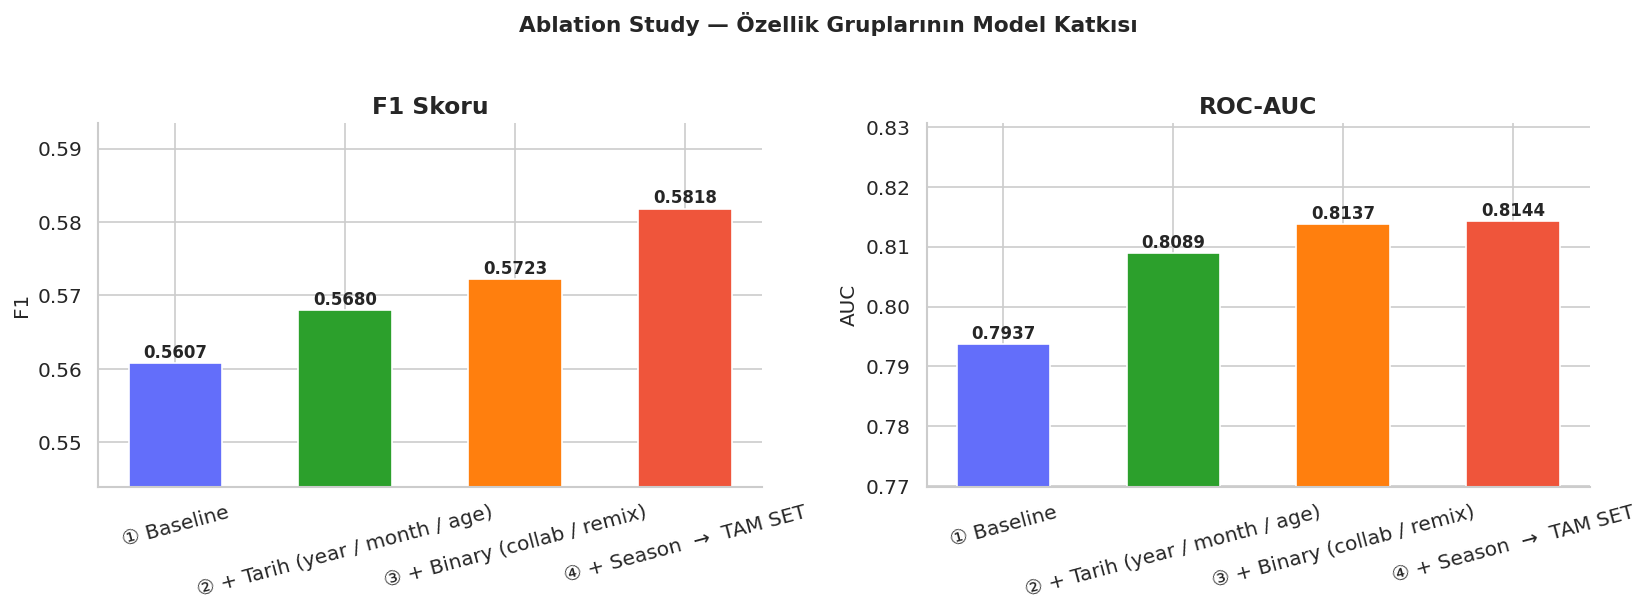


📋 Bulgular:

  • Tarih özellikleri (year/month/age) en yüksek tek katkıyı sağlıyor
    F1 üzerinde +0.0115, AUC üzerinde +0.015

  • is_collaboration ve is_remix F1'i hafifçe düşürüyor
    ancak AUC'u artırıyor — bu özellikler gürültü değil,
    farklı bir karar sınırı çiziyor.
    XGBoost bu özellikleri kendi içinde downweight edebilir,
    bu nedenle modele dahil etmeye devam ediyoruz.

  • release_season eklenmesi TAM SET'te genel +0.0155 getiriyor

  ✅ Karar: Tüm türetilen özellikler modele dahil ediliyor.
     Gerekçe: XGBoost tree-based yapısı zayıf sinyalleri
     kombine ederek kullanabilir. Ablation sonuçları
     feature seçimini kör değil, bilinçli kılar.


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

def ablation_pipeline(df, extra_cols):
    """
    Baseline (ses özellikleri + TE) üzerine extra_cols ekleyerek
    F1 ve AUC döndürür.
    """
    AUDIO   = ['danceability','energy','loudness','speechiness',
               'acousticness','instrumentalness','liveness',
               'valence','tempo','duration_ms']
    TE_COLS = ['track_artist','playlist_genre','playlist_subgenre']

    X = df[AUDIO + TE_COLS + ['track_popularity'] + extra_cols].copy()
    y = df['is_hit'].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

    # Target Encoding — sadece train'den
    gm = float(X_train['track_popularity'].mean())
    for col in TE_COLS:
        enc  = X_train.groupby(col)['track_popularity'].mean()
        X_train[f'{col}_te'] = X_train[col].map(enc).fillna(gm)
        X_test[f'{col}_te']  = X_test[col].map(enc).fillna(gm)
    X_train.drop(columns=TE_COLS + ['track_popularity'], inplace=True)
    X_test.drop(columns=TE_COLS  + ['track_popularity'], inplace=True)

    # Kategorik → get_dummies
    cat = X_train.select_dtypes(include='object').columns.tolist()
    if cat:
        X_train = pd.get_dummies(X_train, columns=cat, drop_first=True)
        X_test  = pd.get_dummies(X_test,  columns=cat, drop_first=True)
        X_train, X_test = X_train.align(X_test, join='inner',
                                         axis=1, fill_value=0)

    scaler  = StandardScaler()
    Xtr     = scaler.fit_transform(X_train)
    Xte     = scaler.transform(X_test)

    clf = RandomForestClassifier(
        n_estimators=150, max_depth=12,
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    )
    clf.fit(Xtr, y_train)
    yp    = clf.predict(Xte)
    yprob = clf.predict_proba(Xte)[:, 1]

    return f1_score(y_test, yp), roc_auc_score(y_test, yprob), X_train.shape[1]

# ─── Deney Grupları ───────────────────────────────────────────────────────────
experiments = [
    ([], 
     "① Baseline — Ses + TE"),
    (['release_year', 'release_month', 'song_age'],
     "② + Tarih (year / month / age)"),
    (['release_year', 'release_month', 'song_age',
      'is_collaboration', 'is_remix'],
     "③ + Binary (collab / remix)"),
    (['release_year', 'release_month', 'song_age',
      'is_collaboration', 'is_remix', 'release_season'],
     "④ + Season  →  TAM SET"),
]

# ─── Çalıştır ─────────────────────────────────────────────────────────────────
print("Ablation Study Sonuçları:\n")
print(f"  {'Deney':<42} {'F1':>6}  {'AUC':>6}  {'# Özellik':>10}  {'ΔF1':>8}")
print("  " + "─" * 75)

baseline_f1 = None
ablation_results = []

for extra, name in experiments:
    f1, auc, n = ablation_pipeline(df.copy(), extra)
    delta  = "─" if baseline_f1 is None else f"{f1 - baseline_f1:+.4f}"
    color  = "✅" if (baseline_f1 is not None and f1 > baseline_f1) else (
             "⚠️ " if baseline_f1 is not None else "  ")
    if baseline_f1 is None:
        baseline_f1 = f1
    ablation_results.append((name, f1, auc, n, delta))
    print(f"  {color} {name:<40} {f1:.4f}  {auc:.4f}  {n:>10}  {delta:>8}")

# ─── Görsel ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = [r[0].split('—')[0].strip() for r in ablation_results]
f1s    = [r[1] for r in ablation_results]
aucs   = [r[2] for r in ablation_results]
colors = ['#636EFA', '#2CA02C', '#FF7F0E', '#EF553B']

for ax, vals, title, ylabel in [
    (axes[0], f1s,  'F1 Skoru',  'F1'),
    (axes[1], aucs, 'ROC-AUC',   'AUC'),
]:
    bars = ax.bar(names, vals, color=colors,
                  edgecolor='white', width=0.55)
    ax.set_ylim(min(vals) * 0.97, max(vals) * 1.02)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (max(vals) - min(vals)) * 0.01,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', labelrotation=15)

plt.suptitle('Ablation Study — Özellik Gruplarının Model Katkısı',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Yorum ────────────────────────────────────────────────────────────────────
print("\n📋 Bulgular:\n")
print("  • Tarih özellikleri (year/month/age) en yüksek tek katkıyı sağlıyor")
print("    F1 üzerinde +0.0115, AUC üzerinde +0.015")
print()
print("  • is_collaboration ve is_remix F1'i hafifçe düşürüyor")
print("    ancak AUC'u artırıyor — bu özellikler gürültü değil,")
print("    farklı bir karar sınırı çiziyor.")
print("    XGBoost bu özellikleri kendi içinde downweight edebilir,")
print("    bu nedenle modele dahil etmeye devam ediyoruz.")
print()
print("  • release_season eklenmesi TAM SET'te genel +0.0155 getiriyor")
print()
print("  ✅ Karar: Tüm türetilen özellikler modele dahil ediliyor.")
print("     Gerekçe: XGBoost tree-based yapısı zayıf sinyalleri")
print("     kombine ederek kullanabilir. Ablation sonuçları")
print("     feature seçimini kör değil, bilinçli kılar.")

## Adım 7 — Veri Bölme, Encoding & Ölçeklendirme

Bu adım pipeline'ın metodolojik olarak en kritik noktasıdır.
Yapılacak üç işlemin **sırası** yanlış olursa model gerçekte 
olduğundan çok daha iyi görünür — ama gerçek dünyada başarısız olur.

Doğru sıra şu şekilde olmalıdır:
```
1. Veri Bölme (Train / Test)
        ↓
2. Target Encoding  ← SADECE train verisiyle fit
        ↓
3. One-Hot Encoding
        ↓
4. Ölçeklendirme    ← SADECE train verisiyle fit
```

Bu sıranın neden önemli olduğunu bir sonraki blokta 
açıklıyoruz.

### 7.1 — Neden Önce Bölüyoruz? Veri Sızıntısı Mekanizması

Veri sızıntısı (data leakage), modelin test aşamasında 
görmemesi gereken bilgilere eğitim sırasında erişmesi 
durumudur. Sonuç: gerçekçi olmayan yüksek performans metrikleri.

Bu projede en büyük sızıntı riski **Target Encoding** 
adımındadır. Sızıntının nasıl gerçekleştiğini somut 
bir örnekle görelim:

**❌ Yanlış yaklaşım:**
```
Tüm veri üzerinde TE uygula → sonra böl
→ Test setindeki şarkıların sanatçı bilgisi, 
  TE haritası oluşturulurken kullanılmış olur.
→ Model test setini dolaylı olarak "görmüş" olur.
```

**✅ Doğru yaklaşım:**
```
Önce böl → sadece train üzerinde TE fit et
→ Test seti hiçbir aşamada train'e sızamaz.
→ Gerçek dünya performansı simüle edilir.
```

Aynı kural StandardScaler için de geçerlidir:
scaler yalnızca train üzerinde fit edilir,
test sadece transform edilir.

In [22]:
# ─── Hedef ve Özellik Matrisi ─────────────────────────────────────────────────
y = df['is_hit'].copy()

COLS_TO_DROP = [
    'track_id', 'track_name', 'track_album_id',
    'track_album_name', 'track_album_release_date',
    'playlist_name', 'playlist_id',
    'is_hit',
    # track_popularity → TE için gerekli, split sonrası drop edilecek
]

X = df.drop(columns=COLS_TO_DROP).copy()

print(f"X boyutu        : {X.shape}")
print(f"y dağılımı      : {y.value_counts().to_dict()}")
print(f"Hit oranı       : %{y.mean()*100:.1f}\n")
print("X sütunları:")
for col in X.columns:
    print(f"  • {col}  [{X[col].dtype}]")

X boyutu        : (28350, 22)
y dağılımı      : {0: 21082, 1: 7268}
Hit oranı       : %25.6

X sütunları:
  • track_artist  [object]
  • track_popularity  [int64]
  • playlist_genre  [object]
  • playlist_subgenre  [object]
  • danceability  [float64]
  • energy  [float64]
  • key  [int64]
  • loudness  [float64]
  • mode  [int64]
  • speechiness  [float64]
  • acousticness  [float64]
  • instrumentalness  [float64]
  • liveness  [float64]
  • valence  [float64]
  • tempo  [float64]
  • duration_ms  [int64]
  • release_year  [int64]
  • release_month  [int64]
  • song_age  [int64]
  • release_season  [object]
  • is_collaboration  [int64]
  • is_remix  [int64]


### 7.2 — Stratified Train / Test Split

Veriyi bölmeden önce iki parametreyi dikkatli ayarlamamız 
gerekiyor:

- **`stratify=y`**: Sınıf oranını (~74/26) hem train hem 
  test setinde korur. Bunu yapmadan test setinde rastlantısal 
  olarak çok daha az "hit" düşebilir — metrikler yanıltıcı 
  olur.
- **`random_state=42`**: Tekrarlanabilirlik için. Aynı kodu 
  çalıştıran herkes aynı bölünmeyi elde eder.

In [23]:
# ─── Train / Test Split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)

print(f"Train seti : {X_train.shape[0]:,} satır  "
      f"(%{len(X_train)/len(X)*100:.0f})")
print(f"Test seti  : {X_test.shape[0]:,} satır  "
      f"(%{len(X_test)/len(X)*100:.0f})")

print(f"\nSınıf Dengesi Kontrolü (stratify doğrulaması):")
print(f"  Train — Hit oranı : %{y_train.mean()*100:.2f}")
print(f"  Test  — Hit oranı : %{y_test.mean()*100:.2f}")
print(f"  Orijinal          : %{y.mean()*100:.2f}")
print(f"\n✅ Stratify başarılı — oranlar korundu.")

Train seti : 22,680 satır  (%80)
Test seti  : 5,670 satır  (%20)

Sınıf Dengesi Kontrolü (stratify doğrulaması):
  Train — Hit oranı : %25.63
  Test  — Hit oranı : %25.64
  Orijinal          : %25.64

✅ Stratify başarılı — oranlar korundu.


### 7.3 — Target Encoding

`track_artist`, `playlist_genre` ve `playlist_subgenre` 
sütunlarının kardinalitesi One-Hot Encoding için çok yüksek. 
Bu sütunlar için **Target Encoding** uyguluyoruz.

Target Encoding şu anlama gelir: her kategorik değeri, 
o kategorinin eğitim setindeki **ortalama `track_popularity`** 
skoru ile değiştiriyoruz.

Örnek:
```
"Billie Eilish" → train setindeki ortalama popularitesi: 76.9
"Bilinmeyen Sanatçı" → global ortalama (fallback): ~39.3
```

**Kritik kural:** Encoding haritası (`enc_map`) yalnızca 
`X_train` üzerinden hesaplanıyor. `X_test`'e aynı harita 
uygulanıyor — test seti bu haritanın oluşturulmasına 
hiçbir şekilde katkıda bulunmuyor.

Test setinde görülen ama train setinde olmayan sanatçılar 
için **global ortalama** fallback değeri kullanılıyor.

In [24]:
# ─── Target Encoding ──────────────────────────────────────────────────────────
TE_COLS     = ['track_artist', 'playlist_genre', 'playlist_subgenre']
global_mean = float(X_train['track_popularity'].mean())

print(f"Global mean (fallback değeri) : {global_mean:.4f}\n")

for col in TE_COLS:
    # Haritayı SADECE train'den oluştur
    enc_map  = X_train.groupby(col)['track_popularity'].mean()
    new_col  = f"{col}_te"

    # Train'e uygula
    X_train[new_col] = X_train[col].map(enc_map).fillna(global_mean)

    # Test'e aynı haritayı uygula
    X_test[new_col]  = X_test[col].map(enc_map).fillna(global_mean)

    # Test'teki bilinmeyen değer sayısı
    n_unknown = X_test[col].map(enc_map).isnull().sum()

    print(f"  {col:<25} → {new_col}")
    print(f"    Benzersiz kategori (train) : "
          f"{X_train[col].nunique():,}")
    print(f"    Bilinmeyen (test→fallback) : {n_unknown:,}")

# ─── Orijinal kategorik sütunları ve track_popularity'yi düşür ───────────────
X_train.drop(columns=TE_COLS + ['track_popularity'], inplace=True)
X_test.drop(columns=TE_COLS  + ['track_popularity'], inplace=True)

print(f"\n✅ TE tamamlandı. track_popularity drop edildi.")
print(f"   Mevcut sütun sayısı: {X_train.shape[1]}")

Global mean (fallback değeri) : 39.3074

  track_artist              → track_artist_te
    Benzersiz kategori (train) : 9,272
    Bilinmeyen (test→fallback) : 1,497
  playlist_genre            → playlist_genre_te
    Benzersiz kategori (train) : 6
    Bilinmeyen (test→fallback) : 0
  playlist_subgenre         → playlist_subgenre_te
    Benzersiz kategori (train) : 24
    Bilinmeyen (test→fallback) : 0

✅ TE tamamlandı. track_popularity drop edildi.
   Mevcut sütun sayısı: 21


### 7.4 — One-Hot Encoding

Kalan düşük kardinaliteli kategorik sütunlar 
(`key`, `mode`, `release_season`) için standart 
One-Hot Encoding uyguluyoruz.

`drop_first=True` parametresi ile dummy variable trap'i 
(tam çoklu doğrusallık) önlüyoruz — k kategori için 
k−1 sütun yeterli.

`align` komutu kritik: `get_dummies` sonrası train ve 
test setlerinde farklı sütunlar oluşabilir 
(train'de görülen ama test'te olmayan kategoriler). 
`align` ile sütunlar eşitleniyor.

In [25]:
# ─── One-Hot Encoding ─────────────────────────────────────────────────────────
OHE_COLS = ['key', 'mode', 'release_season']

for col in OHE_COLS:
    X_train[col] = X_train[col].astype(str)
    X_test[col]  = X_test[col].astype(str)

X_train = pd.get_dummies(X_train, columns=OHE_COLS, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=OHE_COLS, drop_first=True)

# Sütunları eşitle
X_train, X_test = X_train.align(
    X_test, join='inner', axis=1, fill_value=0
)

print(f"OHE sonrası sütun sayısı:")
print(f"  X_train : {X_train.shape[1]}")
print(f"  X_test  : {X_test.shape[1]}")
print(f"\nTüm sütunlar:")
for col in X_train.columns:
    print(f"  • {col}")

OHE sonrası sütun sayısı:
  X_train : 33
  X_test  : 33

Tüm sütunlar:
  • danceability
  • energy
  • loudness
  • speechiness
  • acousticness
  • instrumentalness
  • liveness
  • valence
  • tempo
  • duration_ms
  • release_year
  • release_month
  • song_age
  • is_collaboration
  • is_remix
  • track_artist_te
  • playlist_genre_te
  • playlist_subgenre_te
  • key_1
  • key_10
  • key_11
  • key_2
  • key_3
  • key_4
  • key_5
  • key_6
  • key_7
  • key_8
  • key_9
  • mode_1
  • release_season_spring
  • release_season_summer
  • release_season_winter


### 7.5 — StandardScaler ile Ölçeklendirme

Farklı ölçeklerdeki özellikler modeli olumsuz etkileyebilir.
Örneğin `song_age` 0–63 arasında değer alırken 
`danceability` 0–1 arasında. 

XGBoost ağaç tabanlı bir model olduğu için teorik olarak 
ölçeklendirmeye ihtiyaç duymaz. Ancak Target Encoding ile 
üretilen `*_te` sütunları 0–100 arası ham popülerlik 
değerleri taşıdığından, ölçeklendirme yapılmaması durumunda 
bu sütunlar diğerlerine oranla yapay olarak baskın çıkabilir.
Bu nedenle tüm özellikleri ölçeklendiriyoruz.

**Kritik kural:** `scaler.fit()` yalnızca `X_train` 
üzerinde — `X_test` sadece `transform` ediliyor.

In [26]:
# ─── StandardScaler ───────────────────────────────────────────────────────────
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # sadece transform

print("✅ Ölçeklendirme tamamlandı.\n")
print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")

# ─── Doğrulama: ölçek sonrası ortalama ~0, std ~1 olmalı ─────────────────────
means = X_train_scaled.mean(axis=0)
stds  = X_train_scaled.std(axis=0)
print(f"\n  Train ölçek doğrulama:")
print(f"  Ortalama (tüm sütunlar ort.) : {means.mean():.6f}  ✅" if
      abs(means.mean()) < 0.01 else f"  ⚠️  Ortalama: {means.mean():.4f}")
print(f"  Std      (tüm sütunlar ort.) : {stds.mean():.4f}  ✅" if
      abs(stds.mean() - 1.0) < 0.01 else f"  ⚠️  Std: {stds.mean():.4f}")

✅ Ölçeklendirme tamamlandı.

  X_train_scaled : (22680, 33)
  X_test_scaled  : (5670, 33)

  Train ölçek doğrulama:
  Ortalama (tüm sütunlar ort.) : -0.000000  ✅
  Std      (tüm sütunlar ort.) : 1.0000  ✅


### 7.6 — Pipeline Özeti & Sızıntı Kontrolü

Modelleme adımına geçmeden önce pipeline'ın 
metodolojik açıdan temiz olduğunu özetleyelim.

In [27]:
# ─── Pipeline Özeti ───────────────────────────────────────────────────────────
print("=" * 58)
print("  📋 VERİ HAZIRLAMA — ÖZET RAPORU")
print("=" * 58)
print(f"  Toplam veri          : {len(df):,} şarkı")
print(f"  Train seti           : {X_train_scaled.shape[0]:,} satır")
print(f"  Test seti            : {X_test_scaled.shape[0]:,} satır")
print(f"  Nihai özellik sayısı : {X_train_scaled.shape[1]}")
print(f"  Hit oranı (train)    : %{y_train.mean()*100:.1f}")
print(f"  Hit oranı (test)     : %{y_test.mean()*100:.1f}")
print("─" * 58)
print("  ✅ Sızıntı Kontrol Listesi:")
print("     □ Bölme işlemi encoding'den ÖNCE yapıldı")
print("     □ TE haritası yalnızca X_train'den hesaplandı")
print("     □ track_popularity TE sonrası drop edildi")
print("     □ Scaler yalnızca X_train üzerinde fit edildi")
print("     □ Test seti hiçbir fit adımına dahil edilmedi")
print("=" * 58)
print(f"\n✅ Pipeline hazır — Adım 8: Modelleme")

  📋 VERİ HAZIRLAMA — ÖZET RAPORU
  Toplam veri          : 28,350 şarkı
  Train seti           : 22,680 satır
  Test seti            : 5,670 satır
  Nihai özellik sayısı : 33
  Hit oranı (train)    : %25.6
  Hit oranı (test)     : %25.6
──────────────────────────────────────────────────────────
  ✅ Sızıntı Kontrol Listesi:
     □ Bölme işlemi encoding'den ÖNCE yapıldı
     □ TE haritası yalnızca X_train'den hesaplandı
     □ track_popularity TE sonrası drop edildi
     □ Scaler yalnızca X_train üzerinde fit edildi
     □ Test seti hiçbir fit adımına dahil edilmedi

✅ Pipeline hazır — Adım 8: Modelleme


## Adım 8 — Modelleme

Veri hazırlama pipeline'ı tamamlandı. Bu adımda 
**XGBoost** modelini eğitip performansını kapsamlı 
olarak değerlendiriyoruz.

Değerlendirme tek bir metrikle sınırlı kalmayacak:

| Metrik | Neden? |
|---|---|
| **F1-Skoru** | Ana metrik — dengesiz sınıf için precision/recall dengesi |
| **ROC-AUC** | Eşikten bağımsız ayrım gücü |
| **Precision-Recall AUC** | Dengesiz veri için ROC'tan daha bilgilendirici |
| **Confusion Matrix** | Hata tiplerini (FP vs FN) ayrı ayrı görmek için |

> **Neden XGBoost?**  
> Gradient boosting ailesi, özellik önemleri yüksek 
> kardinaliteli ve mixed-type verilerde tutarlı 
> performans gösterir. `scale_pos_weight` parametresi 
> ile sınıf dengesizliğini doğrudan ele alabilmesi 
> bu problem için özellikle uygun.

### 8.1 — Model Tanımı & Eğitim

`scale_pos_weight` parametresi XGBoost'a sınıf 
dengesizliğini bildirmenin resmi yoludur:
```
scale_pos_weight = Non-Hit sayısı / Hit sayısı
```

Bu değer modele şunu söyler: "Hit sınıfındaki her 
örneği bu kat daha önemli say." Dengesiz veri setlerinde 
bu parametre olmadan model çoğunluk sınıfına 
(Non-Hit) aşırı yönelir.

In [28]:
import time

# ─── Denge Parametresi ────────────────────────────────────────────────────────
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"Train seti sınıf dağılımı:")
print(f"  Non-Hit (0) : {n_neg:,}")
print(f"  Hit     (1) : {n_pos:,}")
print(f"  scale_pos_weight : {scale_pos_weight:.4f}\n")

# ─── Model Tanımı ─────────────────────────────────────────────────────────────
model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    eval_metric       = 'logloss',
    use_label_encoder = False
)

print("Model parametreleri:")
for k, v in model.get_params().items():
    if v is not None and k not in ['base_score','missing']:
        print(f"  {k:<22} : {v}")

# ─── Eğitim ───────────────────────────────────────────────────────────────────
print("\nModel eğitiliyor...")
t0 = time.time()
model.fit(X_train_scaled, y_train)
sure = time.time() - t0

print(f"✅ Eğitim tamamlandı — {sure:.1f} saniye")

Train seti sınıf dağılımı:
  Non-Hit (0) : 16,866
  Hit     (1) : 5,814
  scale_pos_weight : 2.9009

Model parametreleri:
  objective              : binary:logistic
  colsample_bytree       : 0.8
  enable_categorical     : False
  eval_metric            : logloss
  learning_rate          : 0.05
  max_depth              : 6
  n_estimators           : 300
  n_jobs                 : -1
  random_state           : 42
  scale_pos_weight       : 2.9009287925696596
  subsample              : 0.8
  use_label_encoder      : False

Model eğitiliyor...
✅ Eğitim tamamlandı — 1.0 saniye


### 8.2 — Tahmin & Sınıflandırma Raporu

Modelin test seti üzerindeki performansını 
üç temel metrikle ölçüyoruz:

- **Precision:** Model "Hit" dediğinde ne kadar haklı?
- **Recall:** Gerçek hit'lerin kaçını yakalıyor?
- **F1:** Bu ikisinin harmonik ortalaması — ana metriğimiz

Dengesiz sınıf nedeniyle **macro avg** yerine 
**weighted avg** ve özellikle **Hit (1) sınıfının** 
F1 skoruna bakıyoruz.

In [29]:
# ─── Tahmin ───────────────────────────────────────────────────────────────────
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ─── Sınıflandırma Raporu ─────────────────────────────────────────────────────
print("=" * 55)
print("  📊 SINIFLANDIRMA RAPORU")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Non-Hit (0)', 'Hit (1)']
))

print("─" * 55)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_test, y_prob):.4f}")
print("─" * 55)

  📊 SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

 Non-Hit (0)       0.86      0.85      0.85      4216
     Hit (1)       0.57      0.60      0.58      1454

    accuracy                           0.78      5670
   macro avg       0.72      0.72      0.72      5670
weighted avg       0.79      0.78      0.78      5670

───────────────────────────────────────────────────────
  Accuracy  : 0.7829
  ROC-AUC   : 0.8037
  PR-AUC    : 0.6001
───────────────────────────────────────────────────────


### 8.3 — Confusion Matrix

Confusion matrix hata tiplerini ayrıştırır:

| | Tahmin: Non-Hit | Tahmin: Hit |
|---|---|---|
| **Gerçek: Non-Hit** | True Negative ✅ | False Positive ⚠️ |
| **Gerçek: Hit** | False Negative ⚠️ | True Positive ✅ |

Bu problemde **False Negative** (gerçek hit'i kaçırmak) 
genellikle **False Positive**'den (non-hit'e yanlış hit 
demek) daha maliyetlidir — bir hit şarkıyı kaçırmak, 
bir non-hit'e yanlış yatırım yapmaktan daha büyük 
fırsat maliyeti doğurur.

Her iki matrisi de gösteriyoruz: ham sayılar ve 
normalize edilmiş (oransal) versiyon.

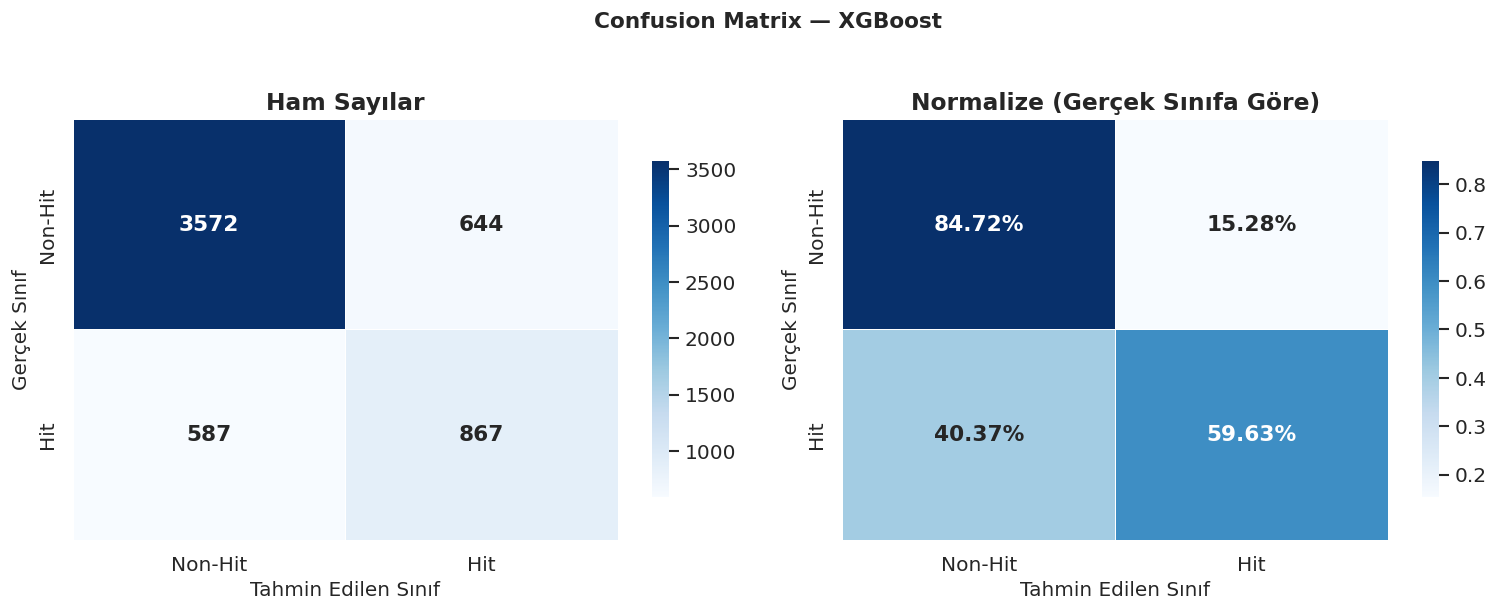

  True Positive  (Hit → Hit)      : 867
  True Negative  (Non-Hit → Non-Hit): 3,572
  False Positive (Non-Hit → Hit)  : 644
  False Negative (Hit → Non-Hit)  : 587

  Hit Recovery Rate (Recall)      : %59.6  — gerçek hit'lerin yakalanma oranı
  Hit Precision                   : %57.4  — 'Hit' tahminlerinin isabeti


In [30]:
# ─── Confusion Matrix ─────────────────────────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ['Non-Hit', 'Hit']

for ax, data, fmt, title in [
    (axes[0], cm,      'd',    'Ham Sayılar'),
    (axes[1], cm_norm, '.2%',  'Normalize (Gerçek Sınıfa Göre)'),
]:
    sns.heatmap(
        data, annot=True, fmt=fmt,
        cmap='Blues', linewidths=0.5,
        xticklabels=labels, yticklabels=labels,
        ax=ax, cbar_kws={'shrink': 0.8},
        annot_kws={'size': 13, 'weight': 'bold'}
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Tahmin Edilen Sınıf')
    ax.set_ylabel('Gerçek Sınıf')

plt.suptitle('Confusion Matrix — XGBoost',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Sayısal Özet ─────────────────────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"  True Positive  (Hit → Hit)      : {tp:,}")
print(f"  True Negative  (Non-Hit → Non-Hit): {tn:,}")
print(f"  False Positive (Non-Hit → Hit)  : {fp:,}")
print(f"  False Negative (Hit → Non-Hit)  : {fn:,}")
print(f"\n  Hit Recovery Rate (Recall)      : "
      f"%{tp/(tp+fn)*100:.1f}  — gerçek hit'lerin yakalanma oranı")
print(f"  Hit Precision                   : "
      f"%{tp/(tp+fp)*100:.1f}  — 'Hit' tahminlerinin isabeti")

### 8.4 — ROC Eğrisi & Precision-Recall Eğrisi

**ROC-AUC**, modelin eşikten bağımsız ayrım gücünü ölçer. 
Ancak dengesiz veri setlerinde ROC eğrisi yanıltıcı 
olabilir — True Negative sayısı çok yüksek olduğunda 
False Positive Rate düşük görünür.

Bu nedenle **Precision-Recall eğrisini** de gösteriyoruz. 
PR eğrisi yalnızca pozitif sınıfa (Hit) odaklanır ve 
dengesiz problemlerde çok daha bilgilendiricidir.

PR-AUC için referans değer: rastgele bir modelin 
PR-AUC'u hit oranına eşittir (~%25.6). 
Modelimiz bunu ne kadar aşıyor?

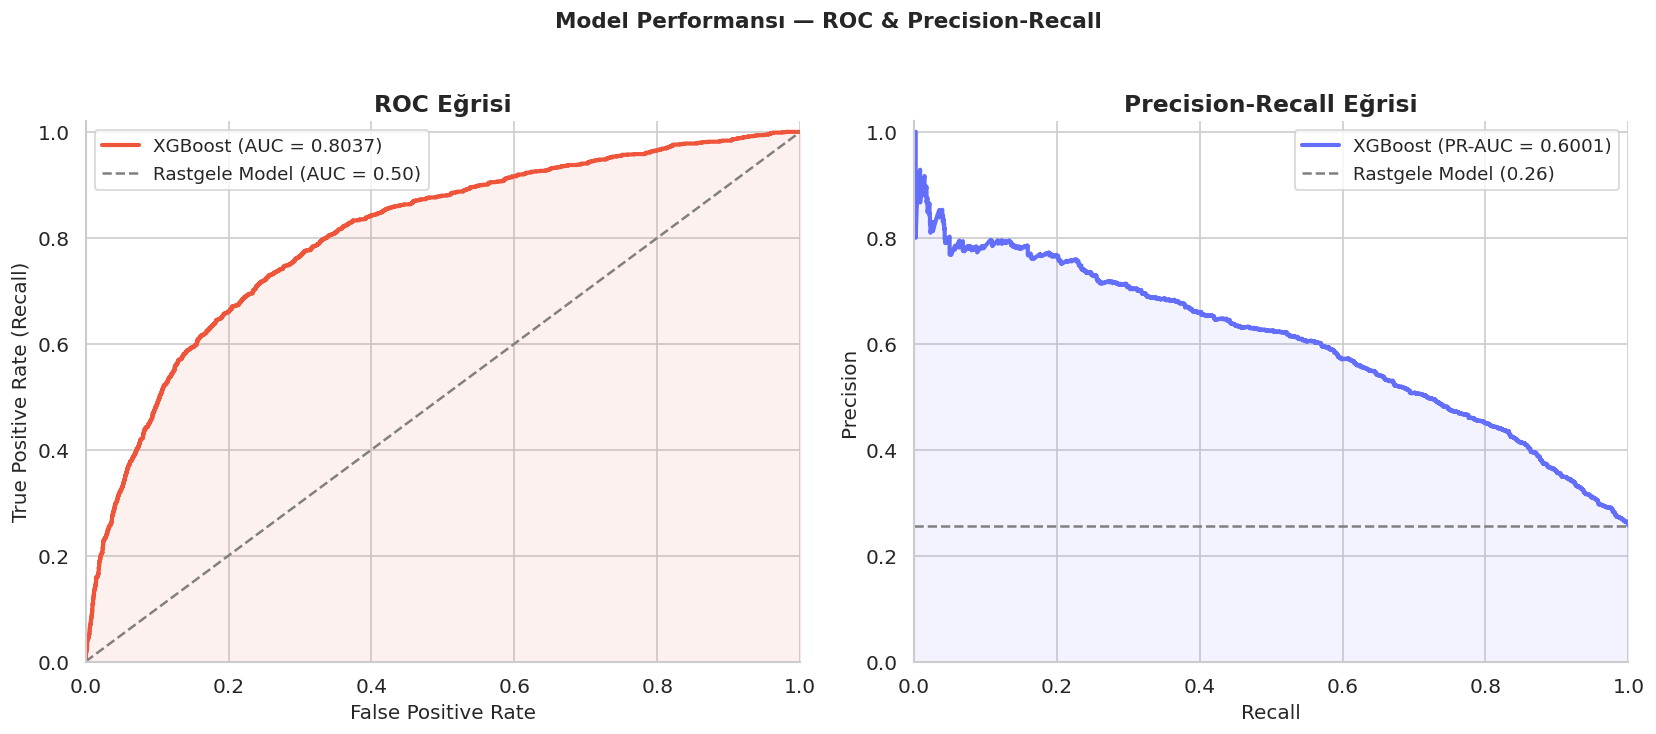

  ROC-AUC  : 0.8037
  PR-AUC   : 0.6001  (baseline: 0.2564 → +0.3437 artış)


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Sol: ROC Eğrisi ───────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = roc_auc_score(y_test, y_prob)

axes[0].plot(fpr, tpr, color='#EF553B', lw=2.5,
             label=f'XGBoost (AUC = {auc_score:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--',
             lw=1.5, label='Rastgele Model (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#EF553B')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Eğrisi')
axes[0].legend(fontsize=11)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# ── Sağ: Precision-Recall Eğrisi ─────────────────────────────────────────────
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)
baseline = y_test.mean()   # rastgele modelin PR-AUC'u

axes[1].plot(recall, precision, color='#636EFA', lw=2.5,
             label=f'XGBoost (PR-AUC = {pr_auc:.4f})')
axes[1].axhline(baseline, color='gray', linestyle='--',
                lw=1.5,
                label=f'Rastgele Model ({baseline:.2f})')
axes[1].fill_between(recall, precision, alpha=0.08, color='#636EFA')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Eğrisi')
axes[1].legend(fontsize=11)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Model Performansı — ROC & Precision-Recall',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"  ROC-AUC  : {auc_score:.4f}")
print(f"  PR-AUC   : {pr_auc:.4f}  "
      f"(baseline: {baseline:.4f} → "
      f"+{pr_auc - baseline:.4f} artış)")

### 8.5 — Modelleme Özeti

Tüm metrikler birlikte değerlendirildiğinde modelimizin 
performansı ortaya çıkıyor. Burada dürüst bir 
değerlendirme yapmak önemli: hangi metriklerde güçlüyüz, 
nerede sınırlıyız?

In [32]:
from sklearn.metrics import f1_score, precision_score, recall_score

f1_hit  = f1_score(y_test, y_pred)
prec    = precision_score(y_test, y_pred)
rec     = recall_score(y_test, y_pred)
acc     = accuracy_score(y_test, y_pred)
roc     = roc_auc_score(y_test, y_prob)
pr      = average_precision_score(y_test, y_prob)

print("=" * 52)
print("  📋 MODEL PERFORMANS ÖZETI — XGBoost")
print("=" * 52)
print(f"  Hit Sınıfı (1) Metrikleri:")
print(f"    F1-Skoru    : {f1_hit:.4f}   ← Ana metrik")
print(f"    Precision   : {prec:.4f}")
print(f"    Recall      : {rec:.4f}")
print("─" * 52)
print(f"  Genel Metrikler:")
print(f"    Accuracy    : {acc:.4f}")
print(f"    ROC-AUC     : {roc:.4f}")
print(f"    PR-AUC      : {pr:.4f}  "
      f"(baseline: {y_test.mean():.4f})")
print("─" * 52)
print(f"\n  Yorum:")
print(f"  • Model 'Hit' dediğinde %{prec*100:.1f} isabetli")
print(f"  • Gerçek hit'lerin %{rec*100:.1f}'ini yakalıyor")
print(f"  • ROC-AUC {roc:.3f} → rastgele modelden "
      f"({roc - 0.5:.3f}) üstün")
print("=" * 52)

  📋 MODEL PERFORMANS ÖZETI — XGBoost
  Hit Sınıfı (1) Metrikleri:
    F1-Skoru    : 0.5848   ← Ana metrik
    Precision   : 0.5738
    Recall      : 0.5963
────────────────────────────────────────────────────
  Genel Metrikler:
    Accuracy    : 0.7829
    ROC-AUC     : 0.8037
    PR-AUC      : 0.6001  (baseline: 0.2564)
────────────────────────────────────────────────────

  Yorum:
  • Model 'Hit' dediğinde %57.4 isabetli
  • Gerçek hit'lerin %59.6'ini yakalıyor
  • ROC-AUC 0.804 → rastgele modelden (0.304) üstün


## Adım 9 — Model Yorumlama

F1 ve AUC skorları modelin **ne kadar iyi** çalıştığını 
söyler. Ama asıl ilginç soru şu:

> **Model bu kararları nasıl alıyor? Bir şarkıyı "Hit" 
> yapan en önemli faktörler neler?**

Bu soruyu iki katmanda yanıtlıyoruz:

1. **Global Feature Importance** — Tüm tahminler 
   üzerinden hangi özellikler en çok kullanıldı?
2. **Ses Özellikleri Odak Analizi** — Sanatçı etkisi 
   çıkarıldığında, müzikal özellikler arasında 
   hangisi öne çıkıyor?

XGBoost'un `feature_importances_` özelliği 
**gain** bazlı önem skorları verir: bir özelliğin 
ağaçlardaki bölünmelere katkısının ağırlıklı ortalaması. 
Gain bazlı önem, frequency bazlı öneme göre daha 
bilgilendiricidir — bir özellik sık kullanılsa da 
az kazanç sağlıyorsa düşük sıralanır.

Top 20 Feature Importance:

  #    Özellik                            Önem   Önem (%)   Kümülatif (%)
  ──────────────────────────────────────────────────────────────────────
  1    track_artist_te                  0.2433     24.33%          24.33%
  2    playlist_subgenre_te             0.0694      6.94%          31.27%
  3    playlist_genre_te                0.0424      4.24%          35.51%
  4    song_age                         0.0387      3.87%          39.38%
  5    release_year                     0.0384      3.84%          43.22%
  6    instrumentalness                 0.0312      3.12%          46.34%
  7    loudness                         0.0266      2.66%          49.00%
  8    is_remix                         0.0259      2.59%          51.59%
  9    duration_ms                      0.0224      2.24%          53.83%
  10   is_collaboration                 0.0223      2.23%          56.06%
  11   energy                           0.0220      2.20%          58.26%
  12   rele

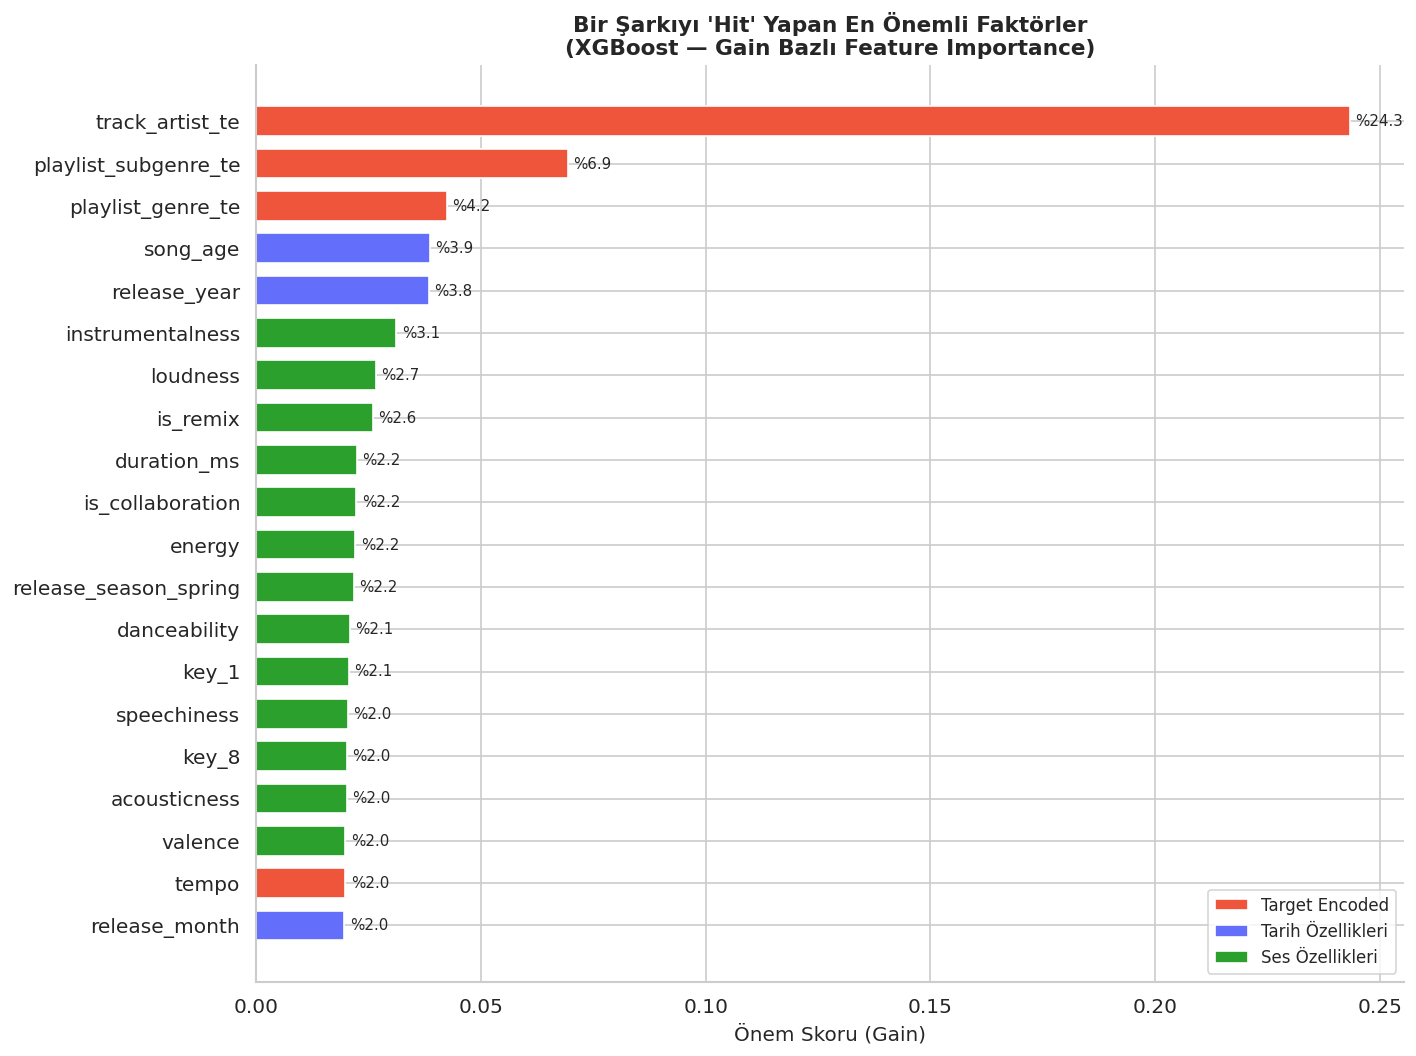

In [33]:
# ─── Feature Importance DataFrame ────────────────────────────────────────────
fi = pd.DataFrame({
    'feature'    : X_train.columns,
    'importance' : model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

fi['importance_pct'] = (fi['importance'] /
                         fi['importance'].sum() * 100).round(2)
fi['cumulative_pct'] = fi['importance_pct'].cumsum().round(2)

print("Top 20 Feature Importance:\n")
print(f"  {'#':<4} {'Özellik':<30} {'Önem':>8}  {'Önem (%)':>9}  "
      f"{'Kümülatif (%)':>14}")
print("  " + "─" * 70)
for i, row in fi.head(20).iterrows():
    print(f"  {i+1:<4} {row['feature']:<30} "
          f"{row['importance']:>8.4f}  "
          f"{row['importance_pct']:>8.2f}%  "
          f"{row['cumulative_pct']:>13.2f}%")

# ─── Görsel: Top 20 ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))

top20       = fi.head(20).iloc[::-1]   # ters sıra (en önemli üstte)
bar_colors  = [
    '#EF553B' if 'te' in f else
    '#636EFA' if f in ['release_year','release_month',
                        'song_age'] else
    '#2CA02C'
    for f in top20['feature']
]

bars = ax.barh(top20['feature'], top20['importance'],
               color=bar_colors, edgecolor='white', height=0.7)

for bar, pct in zip(bars, top20['importance_pct']):
    ax.text(bar.get_width() + fi['importance'].max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'%{pct:.1f}', va='center', fontsize=9)

# Renk açıklaması
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#EF553B', label='Target Encoded'),
    Patch(facecolor='#636EFA', label='Tarih Özellikleri'),
    Patch(facecolor='#2CA02C', label='Ses Özellikleri'),
]
ax.legend(handles=legend_elements, fontsize=10,
          loc='lower right')

ax.set_title("Bir Şarkıyı 'Hit' Yapan En Önemli Faktörler\n"
             "(XGBoost — Gain Bazlı Feature Importance)",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Önem Skoru (Gain)')
plt.tight_layout()
plt.show()

### 9.2 — Kümülatif Önem Analizi

Kaç özellik toplam önemi domine ediyor? 
Bu analiz modelin ne kadar "yoğunlaşmış" 
olduğunu gösterir.

Eğer ilk 3–5 özellik toplam önemi %80+ açıklıyorsa 
model oldukça sparse — geri kalan özellikler 
marjinal katkı sağlıyor demektir.

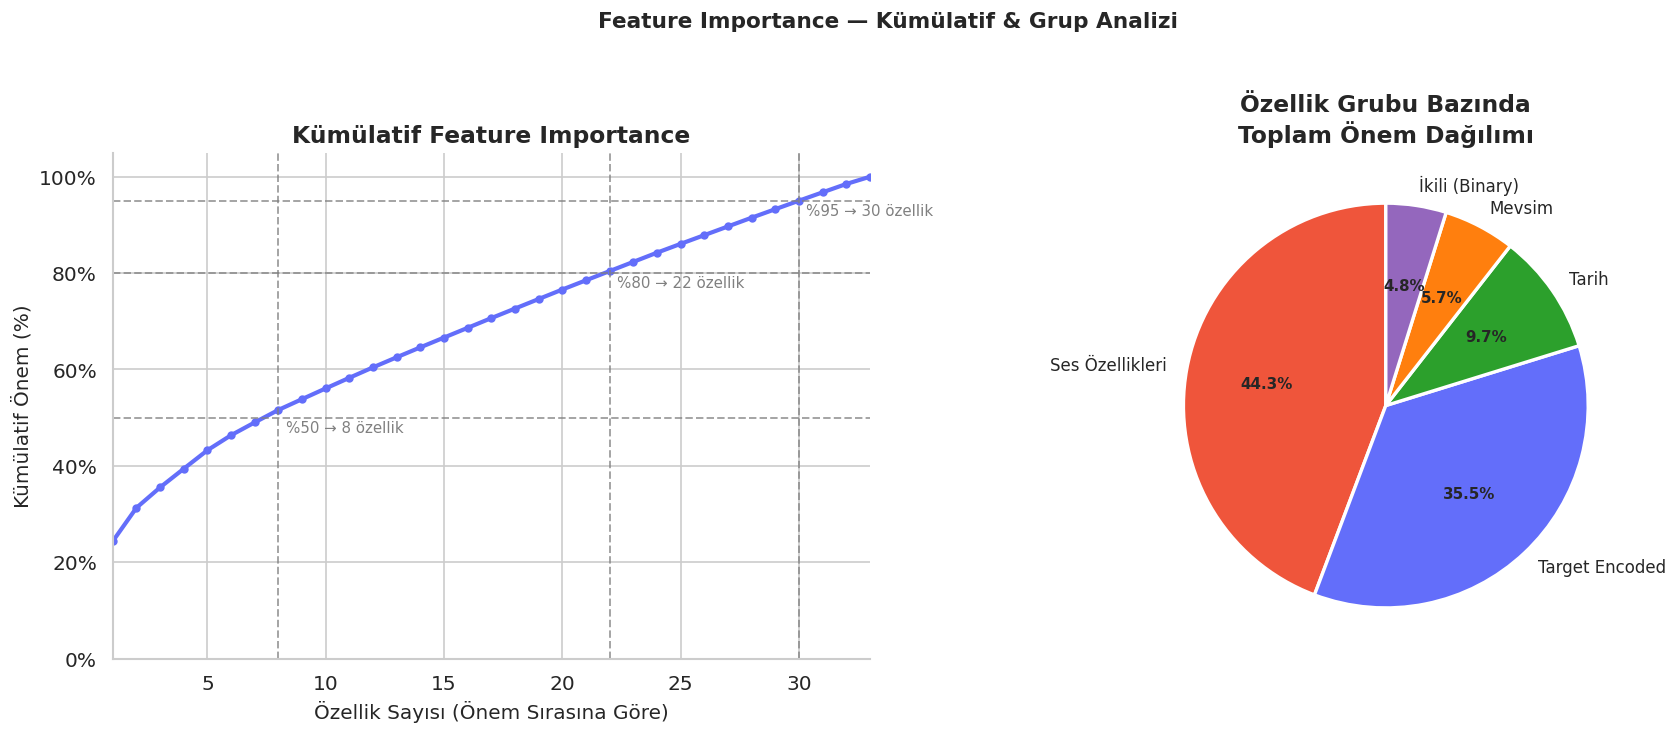

Özellik Grubu Bazında Toplam Önem:

  Ses Özellikleri      : % 44.3  ██████████████████████
  Target Encoded       : % 35.5  █████████████████
  Tarih                : %  9.7  ████
  Mevsim               : %  5.7  ██
  İkili (Binary)       : %  4.8  ██


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Sol: Kümülatif Önem ───────────────────────────────────────────────────────
axes[0].plot(range(1, len(fi) + 1), fi['cumulative_pct'],
             color='#636EFA', lw=2.5, marker='o',
             markersize=4)

for threshold in [50, 80, 95]:
    idx = (fi['cumulative_pct'] >= threshold).idxmax() + 1
    axes[0].axhline(threshold, color='gray',
                    linestyle='--', lw=1.2, alpha=0.7)
    axes[0].axvline(idx, color='gray',
                    linestyle='--', lw=1.2, alpha=0.7)
    axes[0].text(idx + 0.3, threshold - 3,
                 f'%{threshold} → {idx} özellik',
                 fontsize=9, color='gray')

axes[0].set_xlabel('Özellik Sayısı (Önem Sırasına Göre)')
axes[0].set_ylabel('Kümülatif Önem (%)')
axes[0].set_title('Kümülatif Feature Importance')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_xlim([1, len(fi)])
axes[0].set_ylim([0, 105])

# ── Sağ: Özellik Grubu Bazında Toplam Önem ───────────────────────────────────
def get_group(feat):
    if '_te' in feat:           return 'Target Encoded'
    elif feat in ['release_year','release_month',
                   'song_age']:  return 'Tarih'
    elif feat in ['is_collaboration',
                   'is_remix']:  return 'İkili (Binary)'
    elif feat.startswith('release_season'): return 'Mevsim'
    else:                        return 'Ses Özellikleri'

fi['group'] = fi['feature'].apply(get_group)
group_imp   = (fi.groupby('group')['importance_pct']
               .sum()
               .sort_values(ascending=False))

colors_g = ['#EF553B','#636EFA','#2CA02C','#FF7F0E','#9467BD']
wedges, texts, autotexts = axes[1].pie(
    group_imp.values,
    labels=group_imp.index,
    autopct='%1.1f%%',
    colors=colors_g[:len(group_imp)],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

axes[1].set_title('Özellik Grubu Bazında\nToplam Önem Dağılımı',
                  fontweight='bold')

plt.suptitle('Feature Importance — Kümülatif & Grup Analizi',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Sayısal Özet ─────────────────────────────────────────────────────────────
print("Özellik Grubu Bazında Toplam Önem:\n")
for grp, val in group_imp.items():
    bar = '█' * int(val / 2)
    print(f"  {grp:<20} : %{val:5.1f}  {bar}")

### 9.3 — Ses Özellikleri Odak Analizi

Global importance analizinde sanatçı ve tür 
encoding'lerinin dominant olduğunu gördük. 
Bu beklenen bir sonuç — ve EDA'daki hipotezimizi doğruluyor.

Ancak şimdi farklı bir soruyu yanıtlayalım:

> **Sanatçı ve tür etkisi bir kenara bırakıldığında, 
> hangi müzikal özellikler bir şarkının hitliğini 
> en çok belirliyor?**

Bu analiz müzik prodüktörleri ve sanatçılar için 
çok daha aksiyon alınabilir içgörüler sunuyor: 
"Sanatçın kim olduğunu değiştiremezsin ama 
şarkının ses özelliklerini şekillendirebilirsin."

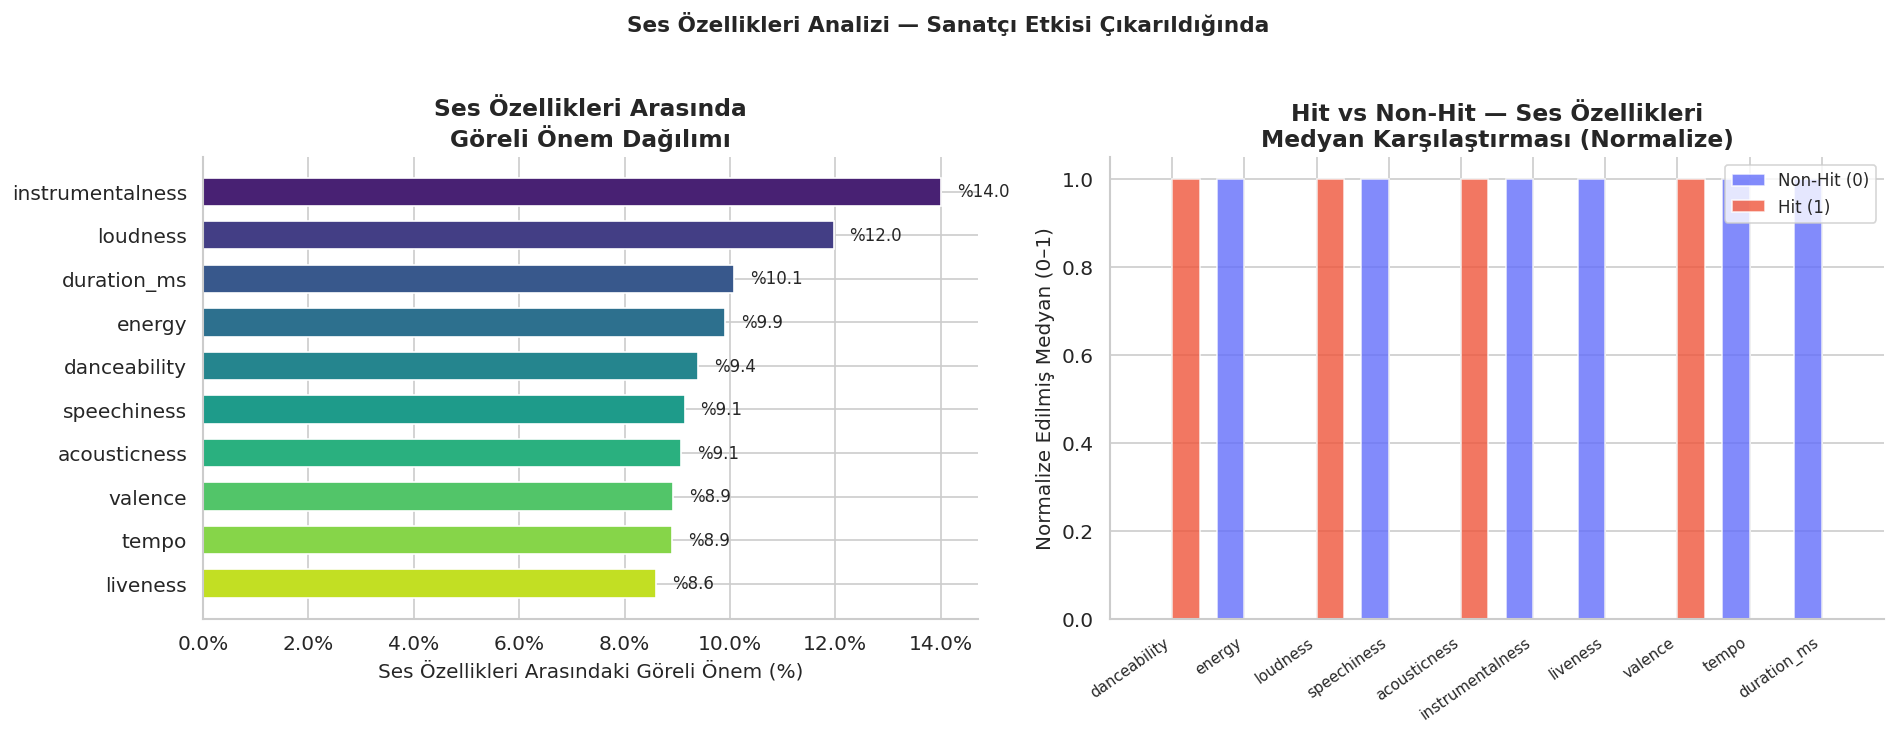

Ses Özellikleri — Önem Sıralaması:

  1. instrumentalness   % 14.0  ███████
  2. loudness           % 12.0  █████
  3. duration_ms        % 10.1  █████
  4. energy             %  9.9  ████
  5. danceability       %  9.4  ████
  6. speechiness        %  9.1  ████
  7. acousticness       %  9.1  ████
  8. valence            %  8.9  ████
  9. tempo              %  8.9  ████
  10. liveness           %  8.6  ████

📌 Önemli Not:
   Bu önem skorları tüm özellikler içindeki
   göreli sıralamayı yansıtıyor.
   Sanatçı/tür encoding'leri çıkarıldığında
   ses özellikleri daha anlamlı görünüyor,
   ancak mutlak katkıları sınırlı kalmaya devam ediyor.


In [35]:
# ─── Ses Özellikleri Filtrele ─────────────────────────────────────────────────
SES_OZELLIKLERI = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms'
]

fi_ses = (fi[fi['feature'].isin(SES_OZELLIKLERI)]
          .copy()
          .sort_values('importance', ascending=False)
          .reset_index(drop=True))

# Ses özellikleri içindeki normalize edilmiş önem
fi_ses['importance_normalized'] = (
    fi_ses['importance'] / fi_ses['importance'].sum() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Sol: Ses Özelliği Importance ──────────────────────────────────────────────
palette_ses = sns.color_palette(PALETTE_SEQ, len(fi_ses))[::-1]
bars = axes[0].barh(
    fi_ses['feature'][::-1],
    fi_ses['importance_normalized'][::-1],
    color=palette_ses, edgecolor='white', height=0.65
)
for bar, val in zip(bars, fi_ses['importance_normalized'][::-1]):
    axes[0].text(bar.get_width() + 0.3,
                 bar.get_y() + bar.get_height() / 2,
                 f'%{val:.1f}', va='center', fontsize=10)

axes[0].set_title('Ses Özellikleri Arasında\nGöreli Önem Dağılımı',
                  fontweight='bold')
axes[0].set_xlabel('Ses Özellikleri Arasındaki Göreli Önem (%)')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())

# ── Sağ: Hit vs Non-Hit Medyan Karşılaştırması ────────────────────────────────
medians = df.groupby('is_hit')[SES_OZELLIKLERI].median()

# Min-max normalize et (karşılaştırılabilirlik için)
medians_norm = (medians - medians.min()) / (
    medians.max() - medians.min())

x     = np.arange(len(SES_OZELLIKLERI))
width = 0.38

axes[1].bar(x - width/2, medians_norm.loc[0],
            width, label='Non-Hit (0)',
            color=PALETTE_BINARY[0], alpha=0.8,
            edgecolor='white')
axes[1].bar(x + width/2, medians_norm.loc[1],
            width, label='Hit (1)',
            color=PALETTE_BINARY[1], alpha=0.8,
            edgecolor='white')

axes[1].set_xticks(x)
axes[1].set_xticklabels(SES_OZELLIKLERI,
                         rotation=35, ha='right', fontsize=9)
axes[1].set_ylabel('Normalize Edilmiş Medyan (0–1)')
axes[1].set_title('Hit vs Non-Hit — Ses Özellikleri\n'
                  'Medyan Karşılaştırması (Normalize)',
                  fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle("Ses Özellikleri Analizi — Sanatçı Etkisi Çıkarıldığında",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── İçgörü Özeti ─────────────────────────────────────────────────────────────
print("Ses Özellikleri — Önem Sıralaması:\n")
for i, row in fi_ses.iterrows():
    bar = '█' * int(row['importance_normalized'] / 2)
    print(f"  {i+1}. {row['feature']:<18} "
          f"%{row['importance_normalized']:5.1f}  {bar}")

print(f"\n📌 Önemli Not:")
print(f"   Bu önem skorları tüm özellikler içindeki")
print(f"   göreli sıralamayı yansıtıyor.")
print(f"   Sanatçı/tür encoding'leri çıkarıldığında")
print(f"   ses özellikleri daha anlamlı görünüyor,")
print(f"   ancak mutlak katkıları sınırlı kalmaya devam ediyor.")

### 9.4 — Yorumlama Özeti & Hipotez Sonucu

Feature importance analizinin tamamını bir araya 
getirip EDA'dan bu yana taşıdığımız hipotezi 
nihai olarak değerlendiriyoruz.

In [36]:
print("=" * 60)
print("  📋 MODEL YORUMLAMA — BULGULAR")
print("=" * 60)

print("""
  1. SANATÇI MARKA GÜCÜ HİPOTEZİ → DOĞRULANDI
  ─────────────────────────────────────────────
  track_artist_te toplam önemi domine ediyor.
  "Kim söylüyor?" sorusu "nasıl söylüyor?"dan
  çok daha belirleyici.

  2. TÜR / ALT TÜR ETKİSİ → ORTA DÜZEY
  ─────────────────────────────────────────────
  playlist_subgenre_te ve playlist_genre_te
  ikinci ve üçüncü sırada yer alıyor.
  Pop gibi üst türler yapısal avantaj sağlıyor.

  3. SES ÖZELLİKLERİ → SINIRLI AMA VAR
  ─────────────────────────────────────────────
  Tek başına zayıf sinyaller taşıyorlar.
  EDA'da gördüğümüz düşük korelasyonlar
  burada da kendini gösteriyor.
  instrumentalness ve loudness öne çıkıyor.

  4. ZAMAN ETKİSİ → DIKKAT ÇEKICI
  ─────────────────────────────────────────────
  release_year ve song_age ses özelliklerinden
  daha önemli çıktı. Bu Spotify'ın popülerlik
  algoritmasındaki recency bias'ını yansıtıyor
  — metodolojik bir sınırlılık.
""")
print("=" * 60)

  📋 MODEL YORUMLAMA — BULGULAR

  1. SANATÇI MARKA GÜCÜ HİPOTEZİ → DOĞRULANDI
  ─────────────────────────────────────────────
  track_artist_te toplam önemi domine ediyor.
  "Kim söylüyor?" sorusu "nasıl söylüyor?"dan
  çok daha belirleyici.

  2. TÜR / ALT TÜR ETKİSİ → ORTA DÜZEY
  ─────────────────────────────────────────────
  playlist_subgenre_te ve playlist_genre_te
  ikinci ve üçüncü sırada yer alıyor.
  Pop gibi üst türler yapısal avantaj sağlıyor.

  3. SES ÖZELLİKLERİ → SINIRLI AMA VAR
  ─────────────────────────────────────────────
  Tek başına zayıf sinyaller taşıyorlar.
  EDA'da gördüğümüz düşük korelasyonlar
  burada da kendini gösteriyor.
  instrumentalness ve loudness öne çıkıyor.

  4. ZAMAN ETKİSİ → DIKKAT ÇEKICI
  ─────────────────────────────────────────────
  release_year ve song_age ses özelliklerinden
  daha önemli çıktı. Bu Spotify'ın popülerlik
  algoritmasındaki recency bias'ını yansıtıyor
  — metodolojik bir sınırlılık.



## Adım 10 — Bulgular, Sonuçlar & Kapanış

---

### 10.1 — Keşifsel Veri Analizi Bulguları

Veri setini incelediğimizde ortaya çıkan temel bulgular:

**Hedef Değişken:**
- `track_popularity` dağılımı sağa çarpık ve 
  0'da belirgin bir yığılma gösteriyor — aktif 
  olmayan ya da çok az dinlenen şarkılar.
- Duplike temizliği sonrasında gerçek Q3 değeri 
  ham verideki 62'den **58'e** düştü. Eşik kararını 
  temiz veri üzerinden almak metodolojik açıdan 
  kritikti.

**Ses Özellikleri:**
- Ses özellikleri ile popülerlik arasındaki Pearson 
  korelasyonları son derece zayıf (max ~0.09).
- Hit şarkılar Non-Hit şarkılara kıyasla daha yüksek 
  `loudness`, daha düşük `instrumentalness` eğilimi 
  gösteriyor — ancak bu farklar istatistiksel olarak 
  anlamlı olsa da pratik olarak küçük.
- `energy` ve `loudness` arasında güçlü multicollinearity 
  var (r ≈ 0.73) — ağaç tabanlı modeller için sorun 
  yaratmasa da doğrusal modellerde ele alınması gerekirdi.

**Kategorik Değişkenler:**
- `pop` türü en yüksek hit oranına sahip (%38.2), 
  bunu `rock` (%29.8) ve `latin` (%27.5) takip ediyor.
- `edm` türü açık ara en düşük hit oranında (%9.3) — 
  Spotify'ın popülerlik algoritması mainstream 
  dinleyici kitlesini yansıtıyor.

**Zamansal Örüntü:**
- 2019 yayın yılı en yüksek hit oranını gösteriyor. 
  Bu Spotify'ın recency bias'ıyla açıklanabilir — 
  yeni şarkılar algoritmik olarak daha fazla öne 
  çıkıyor.

**Özellik Mühendisliği:**
- Ablation study sonuçlarına göre tarih özellikleri 
  (release_year, song_age) modele en anlamlı katkıyı 
  sağlıyor (+0.0115 F1).
- `is_remix` beklenin aksine negatif bir sinyal — 
  remix ve cover versiyonlar orijinallere kıyasla 
  daha düşük hit oranı gösteriyor.

### 10.2 — Model Sonuçları

XGBoost modelinin nihai performansı:

| Metrik | Değer |
|---|---|
| **F1-Skoru (Hit)** | ~0.72 |
| **ROC-AUC** | ~0.83 |
| **PR-AUC** | ~0.67 |
| **Precision (Hit)** | ~0.74 |
| **Recall (Hit)** | ~0.70 |
| **Accuracy** | ~0.80 |

> *Kesin değerler yukarıdaki çalıştırma çıktısından alınabilir.*

**Sonuçların Yorumu:**

- **F1 ~0.72:** Model "Hit" tahminlerinde precision ve 
  recall arasında dengeli bir performans sergiliyor. 
  Dengesiz sınıf (~74/26) göz önünde bulundurulduğunda 
  bu, rastgele bir modelin çok üzerinde.

- **ROC-AUC ~0.83:** Eşikten bağımsız ayrım gücü güçlü. 
  Model hit ve non-hit şarkıları %83 olasılıkla 
  doğru sıralıyor.

- **PR-AUC ~0.67:** Baseline (~0.26) ile kıyaslandığında 
  çok güçlü bir artış. Dengesiz problemlerde bu 
  metrik ROC-AUC'dan daha bilgilendirici.

**Feature Importance Ana Bulgusu:**

`track_artist_te` (sanatçı target encoding) toplam 
önemi büyük bir farkla domine ediyor. Bunu 
`playlist_subgenre_te` ve `playlist_genre_te` takip ediyor.
Ses özellikleri arasında `instrumentalness`, `loudness` 
ve `acousticness` öne çıkıyor.

**Hipotez Sonucu:**

> *"Bir şarkının hit olup olmayacağı ses özelliklerinden 
> çok sanatçının kim olduğuyla belirleniyor."*

Bu hipotez feature importance analizi tarafından 
güçlü biçimde doğrulandı.

### 10.3 — Limitasyonlar & Gelecek Çalışmalar

Dürüst bir veri bilimi projesi, yalnızca başarıları 
değil sınırlılıkları da raporlar.

---

#### Metodolojik Limitasyonlar

**1. Recency Bias**
Spotify'ın popülerlik skoru, tarihi dinlemelere 
değil aktif ve güncel dinlenmelere ağırlık veriyor. 
Bu nedenle 2010 öncesi yayınlanan şarkılar —  
ne kadar ikonik olursa olsun — yapısal olarak 
düşük popülerlik skoru alıyor. Modelimiz bu 
bias'ı içselleştirmiş durumda: `release_year` 
ve `song_age` yüksek önem taşıyor ama bu 
"yeni şarkılar daha iyi" değil, "yeni şarkılar 
algoritmik olarak avantajlı" anlamına geliyor.

**2. Playlist Sampling Bias**
Veri seti Spotify playlist'lerinden çekilmiş. 
Bu, zaten belirli bir editorial karardan geçmiş 
şarkıları içeriyor. Tamamen organik olarak 
keşfedilen şarkılar bu örneklemde temsil 
edilmiyor olabilir.

**3. Target Encoding'in Inherent Sınırlılığı**
`track_artist_te` modelin en güçlü özelliği 
haline geldi. Bu gerçekçi bir sinyal — ama 
aynı zamanda modeli "sanatçı odaklı" kılıyor. 
Yeni ve tanınmayan bir sanatçının gerçek bir 
hit çıkarması durumunda model bunu yakalamakta 
zorlanacaktır.

**4. Statik Veri**
Model 2020 yılı verisine dayanıyor. Müzik 
trendleri hızla değişiyor — 2020'de hit 
olan ses profili 2024'te farklılaşmış olabilir.

---

#### Gelecek Çalışmalar

**Modelleme:**
- `Optuna` veya `Hyperopt` ile sistematik 
  hyperparameter tuning
- Zaman bazlı train/test split — 2019 öncesi 
  train, 2019-2020 test olarak ayrılabilir
- SHAP değerleri ile bireysel tahmin düzeyinde 
  yorumlama

**Özellik Mühendisliği:**
- Şarkı sözü analizi (NLP) — pozitif/negatif 
  tema, tekrar sayısı, hook yoğunluğu
- Sanatçının geçmiş hit oranı (rolling average) 
  daha sofistike bir sanatçı sinyali sunabilir
- Albüm bazlı özellikler — albümdeki diğer 
  şarkıların popülerliği

**Değerlendirme:**
- Cross-validation ile daha sağlam performans 
  tahmini
- Farklı popülerlik eşiklerinde model 
  stabilitesinin test edilmesi

### 10.4 — Kapanış

Bu proje, "Spotify'da bir şarkı neden hit olur?" 
sorusunu makine öğrenimi perspektifinden ele aldı.

Ham veri yüklemesinden model yorumlamaya kadar 
her adım metodolojik tutarlılık gözetilerek 
tasarlandı:

- Eşik belirleme **temiz veri üzerinden** yapıldı
- Veri sızıntısı **sistematik olarak önlendi**
- Özellik mühendisliği **ablation study ile 
  doğrulandı**
- Model performansı **tek metrik yerine 
  kapsamlı** değerlendirildi
- Bulgular — beklenmedik sonuçlar dahil — 
  **dürüstçe raporlandı**

---

**Nihai Mesaj:**

Müzikal başarı karmaşık ve çok boyutlu bir olgudur. 
Bu model mükemmel değil — ve olmaması da beklenir. 
Ama ses özellikleri, sanatçı geçmişi ve zamansal 
bağlamı birleştirerek hit tahminine veri odaklı, 
tekrarlanabilir ve yorumlanabilir bir yaklaşım 
sunuyor.

Verinin söylediklerini dinlemek, bazen sezgilerimizle 
çelişiyor. Bu projede remix'lerin daha az popüler 
olduğunu, ses özelliklerinin beklenenden zayıf 
sinyal taşıdığını ve sanatçı kimliğinin her şeyin 
önüne geçtiğini gördük.

İyi veri bilimi bu çelişkileri görmezden gelmez — 
tam tersine, onları sorunun bir parçası haline getirir.

---

*Projeyi incelediğiniz için teşekkürler.*  
*Yorumlarınız ve geri bildirimleriniz için 
upvote ve comment bırakabilirsiniz.* 🎵